First, create a new conda environment named BI2025 and install the required packages from requirements.txt


In [1]:
# !conda create -n BI2025 python=3.11 -y
# !conda activate BI2025
# !pip install -r requirements.txt

In [2]:
# DO NOT MODIFY OR COPY THIS CELL!! 
# Note: The only imports allowed are Python's standard library, pandas, numpy, scipy, matplotlib, seaborn and scikit-learn
import numpy as np
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import plotly.express as px
import datetime
import typing
import requests
import time
import shutil
import json
from starvers.starvers import TripleStoreEngine

## Graph-based documentation preliminaries

**!!!IMPORTANT!!!**

Everytime you work on this notebook, enter your student ID in the `executed_by` variable so that the cell executions are accredited to you.

In [3]:
executed_by ='stud-id_12433732'  # Replace the digits after "id_" with your own student ID

Set your group and student IDs. Do this only once.

In [4]:
# group id for this project
group_id = '061'  # Replace the digits with your group id

# Students working on this notebook
student_a = 'stud-id_12412672'  # Replace the digits after "id_" with student A's student ID
student_b = 'stud-id_12433732'  # Replace the digits after "id_" with student B's student ID

In [5]:
# Roles. Don't change these values.
code_writer_role = 'code_writer'
code_executor_role = 'code_executor'

Setup the starvers API for logging your steps into our server-sided graph database.

In [6]:
get_endpoint = "https://starvers.ec.tuwien.ac.at/BI2025"
post_endpoint = "https://starvers.ec.tuwien.ac.at/BI2025/statements"
engine = TripleStoreEngine(get_endpoint, post_endpoint, skip_connection_test=True)

Use these prefixes in your notebooks. You can extend this dict with your prefixes of additional ontologies that you use in this notebook. Replace 00 with your group id

In [7]:
prefixes = {
    'xsd': 'http://www.w3.org/2001/XMLSchema#',
    'rdfs': 'http://www.w3.org/2000/01/rdf-schema#',
    'foaf': 'http://xmlns.com/foaf/0.1/',
    'prov': 'http://www.w3.org/ns/prov#',
    'sc': 'https://schema.org/',
    'cr': 'http://mlcommons.org/croissant/',
    'mls': 'http://www.w3.org/ns/mls#',
    'mlso': 'http://w3id.org/mlso',
    'siu': 'https://si-digital-framework.org/SI/units/',
    'siq': 'https://si-digital-framework.org/SI/quantities/',
    'qudt': 'http://qudt.org/schema/qudt/',
    '': f'https://starvers.ec.tuwien.ac.at/BI2025/{group_id}/',
    "dcterms": "http://purl.org/dc/terms/",
}

prefix_header = '\n'.join([f'PREFIX {k}: <{v}>' for k, v in prefixes.items()]) + '\n\n'

Ontologies to use
* Provenance of the experiment process
    * PROV-O: 
        * doc: https://www.w3.org/TR/prov-o/
        * serialization: https://www.w3.org/ns/prov-o
* Data used and created
    * schema.org - Dataset: 
        * doc: https://schema.org/Dataset
        * serialization: https://schema.org/version/latest/schemaorg-current-https.ttl
    * Crossaint
        * doc: https://docs.mlcommons.org/croissant/docs/croissant-spec.html
        * serialization: https://github.com/mlcommons/croissant/blob/main/docs/croissant.ttl
* ML experiments performed
    * MLSO: 
        * doc: https://github.com/dtai-kg/MLSO
        * doc: https://dtai-kg.github.io/MLSO/#http://w3id.org/
        * serialization: https://dtai-kg.github.io/MLSO/ontology.ttl
* Measurements, Metrics, Units
    * QUDT
        * doc:https://qudt.org/
        * doc: https://github.com/qudt/qudt-public-repo
        * serialization: https://github.com/qudt/qudt-public-repo/blob/main/src/main/rdf/schema/SCHEMA_QUDT.ttl
    * SI Digital Framework
        * doc: https://github.com/TheBIPM/SI_Digital_Framework/blob/main/SI_Reference_Point/docs/README.md
        * doc: https://si-digital-framework.org/
        * doc: https://si-digital-framework.org/SI
        * serialization: https://github.com/TheBIPM/SI_Digital_Framework/blob/main/SI_Reference_Point/TTL/si.ttl
    * Quantities and Units
        * doc: https://www.omg.org/spec/Commons
        * serialization: https://www.omg.org/spec/Commons/QuantitiesAndUnits.ttl

Use this function to record execution times.

In [8]:
def now() -> str:
    """
    Returns the current time in ISO 8601 format with UTC timezone in the following format:
    YYYY-MM-DDTHH:MM:SS.sssZ
    """
    timestamp = datetime.datetime.now(datetime.timezone.utc)
    timestamp_formated = timestamp.strftime("%Y-%m-%dT%H:%M:%S.%f")[:-3]  +"Z"

    return timestamp_formated

Register yourself in the Knowledge Graph using ProvO. Change the given name, family name and immatriculation number to reflect your own data.

In [ ]:
# Ontologies used: foaf, prov, IAO
reigstration_triples_a = [
f':{student_a} rdf:type foaf:Person .',
f':{student_a} rdf:type prov:Agent .',
f':{student_a} foaf:givenName "Tim" .',
f':{student_a} foaf:familyName "Greß" .',
f':{student_a} <http://vivoweb.org/ontology/core#identifier> :{student_a} .',
f':{student_a} rdf:type <http://purl.obolibrary.org/obo/IAO_0000578> .',
f':{student_a} <http://www.w3.org/2000/01/rdf-schema#label> "Immatriculation number" .',
f':{student_a} <http://purl.obolibrary.org/obo/IAO_0000219> "12412672"^^xsd:string .',
]

reigstration_triples_b = [
f':{student_b} rdf:type foaf:Person .',
f':{student_b} rdf:type prov:Agent .',
f':{student_b} foaf:givenName "Stefan" .',
f':{student_b} foaf:familyName "Merdian" .',
f':{student_b} <http://vivoweb.org/ontology/core#identifier> :{student_b} .',
f':{student_b} rdf:type <http://purl.obolibrary.org/obo/IAO_0000578> .',
f':{student_b} <http://www.w3.org/2000/01/rdf-schema#label> "Immatriculation number" .',
f':{student_b} <http://purl.obolibrary.org/obo/IAO_0000219> "12433732"^^xsd:string .',
]

role_triples = [
    f':{code_writer_role} rdf:type prov:Role .',
    f':{code_executor_role} rdf:type prov:Role .',
]


engine.insert(reigstration_triples_a, prefixes=prefixes)
engine.insert(reigstration_triples_b, prefixes=prefixes)
engine.insert(role_triples, prefixes=prefixes)

**What not do do**

Do not use [blank nodes](https://www.w3.org/wiki/BlankNodes).

PROV-O uses blank nodes to connect multiple elements with each other.
Such blank nodes (such as _:association) should not be used.
Instead, assign a fixed node ID such as
:5119fcd7-b571-41e0-9464-a37c7be0f574 by generating them outside of the
notebook.
We suggest that, for each setting where such a blank node is needed to
connect multiple elements, you create a unique hash (using uuid.uuid4())
and keep this as hard-coded identifier for the blank node. The template
notebook contains examples of this. Do *not* use these provided values,
as otherwise, your provenance documentations will all be connected via
these identifiers!
Also, do not generate them dynamically in every cell execution, e.g. by
using uuid.uuid4() in a cell. This would generate many new linking nodes
for connecting the same elements.
Compute one for each node (cell) where you need them and make sure to
use the same one on each re-execution of the notebook.

In [ ]:
#add github to Provo
repo_url = "https://github.com/timg4/BusinessIntelligence/"
mit_license = "https://opensource.org/licenses/MIT"

repo_provenance_triples = [
    f'<{repo_url}> rdf:type prov:Entity .',
    f'<{repo_url}> rdfs:label "Project code repository (GitHub)" .',
    f'<{repo_url}> prov:value "{repo_url}" .',
    f'<{repo_url}> dcterms:license <{mit_license}> .',
]

engine.insert(repo_provenance_triples, prefixes=prefixes)

## Business Understanding 

In [ ]:
## Each Activity that follows is part of the Business Understanding Phase

business_understanding_phase_executor = [
f':business_understanding_phase rdf:type prov:Activity .',
f':business_understanding_phase rdfs:label "Business Understanding Phase" .', ## Phase 1: Business Understanding
]
engine.insert(business_understanding_phase_executor, prefixes=prefixes)


In [ ]:
#############################################
# Documentation
#############################################

data_src_and_scenario_comment = """
We use the "NBA Players" dataset from Kaggle (https://www.kaggle.com/datasets/justinas/nba-players-data) provided by Justinas Cirtuatas. It contains one row per player per season for 
the NBA seasons from 1996 to 2022. It includes biographical attributes, biometric attributes and basic box score statistics such as games played, average number of points or assists.

In the scenario we assume that the analytics department of an NBA team wants to have decision support for player acquisitions for the next season. 
The team wants to estimate how impactful a player will be in a season, capture by net_rating which is the difference of points scored and points allowed per 100 possessions 
when the player is on the court. The historical data will be used to build a model which helps to identify players that are undervalued
and helps to avoid signing player with low expected impact.  """

business_objectives_comment = """
1. Identify players that are undervalued in terms of their expected impact on the team's performance for the next season.
2. Avoid signing players with low expected impact to optimize the teams performance and transfer budget utilization.
3. Assist subjective scouting with a quantitative model and make the decisions more interpretable and reproducable.
"""

business_success_criteria_comment = """
1. On the training data at least 70% of the top 25% players by net_rating should be correctly identified as top 25% players by the model.
2. In the top 25% predicted by the model at least 80% of the players should be above the league average net_rating in their next season. 
3. In total the model should reduce the impact of bad signings (players with net_rating below league average) by at least 25% compared to random or 
subjective signings.
"""

data_mining_goals_comment = """
Build a predictive model to support player acquisition decisions. The main goal is to predict a player’s impact using net_rating (regression).
Output will be a predicted net_rating plus a shortlist/ranking of high-impact candidates (e.g. top 25% predicted). 
Use season statistics and basic player attributes as features, we should  not use player_name as a feature. Evaluate  a time-aware way 
(train on earlier seasons, test on later seasons) to reduce look-ahead bias.
"""

data_mining_success_criteria_comment = """
Success is measured on an unseen test set. The model must beat a simple baseline (predicting mean net_rating) using RMSE/MAE. 
Additionally, shortlist quality should be good: selecting the top 25% by predicted net_rating should capture most of the true top performers (high recall in top quartile) 
and the shortlist should have above-average net_rating on average.
"""

ai_risk_aspects_comment = """
Main risks: 
1. bias via proxy variables (e.g., country, draft status) and underrepresented groups
2. selection bias (dataset only includes NBA players) 
3. concept drift over time (style changes) 
4. automation bias if scouts over-trust predictions 
5. privacy/identification risk if using player_name. Mitigate by excluding identifiers, using time-based splits, 
and checking performance across groups (e.g. USA vs non-USA, drafted vs undrafted).
"""


bu_ass_uuid_executor = "9ec26206-f310-4e44-8d4a-4e3baa765c75" \
"" # Generate once
business_understanding_executor = [
f':business_understanding rdf:type prov:Activity .',
f':business_understanding sc:isPartOf :business_understanding_phase .', # Connect Activity to Parent Business Understanding Phase Activity
f':business_understanding prov:qualifiedAssociation :{bu_ass_uuid_executor} .',
f':{bu_ass_uuid_executor} prov:agent :{executed_by} .',
f':{bu_ass_uuid_executor} rdf:type prov:Association .',
f':{bu_ass_uuid_executor} prov:hadRole :{code_executor_role} .',
]
engine.insert(business_understanding_executor, prefixes=prefixes)


business_understanding_data_executor = [
# 1a
f':bu_data_source_and_scenario rdf:type prov:Entity .',
f':bu_data_source_and_scenario prov:wasGeneratedBy :business_understanding .',
f':bu_data_source_and_scenario rdfs:label "1a Data Source and Scenario" .',
f':bu_data_source_and_scenario rdfs:comment """{data_src_and_scenario_comment}""" .',
# 1b
f':bu_business_objectives rdf:type prov:Entity .',
f':bu_business_objectives prov:wasGeneratedBy :business_understanding .',
f':bu_business_objectives rdfs:label "1b Business Objectives" .',
f':bu_business_objectives rdfs:comment """{business_objectives_comment}""" .',
# 1c
f':bu_business_success_criteria rdf:type prov:Entity .',
f':bu_business_success_criteria prov:wasGeneratedBy :business_understanding .',
f':bu_business_success_criteria rdfs:label "1c Business Success Criteria" .',
f':bu_business_success_criteria rdfs:comment """{business_success_criteria_comment}""" .',
# 1d
f':bu_data_mining_goals rdf:type prov:Entity .',
f':bu_data_mining_goals prov:wasGeneratedBy :business_understanding .',
f':bu_data_mining_goals rdfs:label "1d Data Mining Goals" .',
f':bu_data_mining_goals rdfs:comment """{data_mining_goals_comment}""" .',
# 1e
f':bu_data_mining_success_criteria rdf:type prov:Entity .',
f':bu_data_mining_success_criteria prov:wasGeneratedBy :business_understanding .',
f':bu_data_mining_success_criteria rdfs:label "1e Data Mining Success Criteria" .',
f':bu_data_mining_success_criteria rdfs:comment """{data_mining_success_criteria_comment}""" .',
# 1f
f':bu_ai_risk_aspects rdf:type prov:Entity .',
f':bu_ai_risk_aspects prov:wasGeneratedBy :business_understanding .',
f':bu_ai_risk_aspects rdfs:label "1f AI risk aspects" .',
f':bu_ai_risk_aspects rdfs:comment """{ai_risk_aspects_comment}""" .',

]
engine.insert(business_understanding_data_executor, prefixes=prefixes)

## Data Understanding

The following pseudo-code & pseudo-documentation may be used as a hint.

In [ ]:
## Each Activity that follows is part of the Data Understanding Phase

business_understanding_phase_executor = [
f':data_understanding_phase rdf:type prov:Activity .',
f':data_understanding_phase rdfs:label "Data Understanding Phase" .', 
]
engine.insert(business_understanding_phase_executor, prefixes=prefixes)


In [ ]:
nba_data_path = os.path.join("data", "all_seasons.csv")
load_nba_data_code_writer = student_a

def load_nba_data()-> pd.DataFrame:
    
    input_file = nba_data_path
    raw_data = pd.read_csv(input_file,  sep=',', header = 0)
    return raw_data

start_time_ld = now()
data = load_nba_data()   # 'data' is our main working DataFrame
end_time_ld = now()

#############################################
# Documentation
#############################################

# Now document the raw data and the loaded data using appropriate ontologies.

# Always add these triples for every activity to define the executor!
ld_ass_uuid_executor = "225e7288-90a0-4cc8-888d-4c4d62316bfe" # Generate once
load_nba_data_executor = [
    f':load_nba_data prov:qualifiedAssociation :{ld_ass_uuid_executor} .',
    f':{ld_ass_uuid_executor} prov:agent :{executed_by} .',
    f':{ld_ass_uuid_executor} rdf:type prov:Association .',
    f':{ld_ass_uuid_executor} prov:hadRole :{code_executor_role} .',
]
engine.insert(load_nba_data_executor, prefixes=prefixes)

ld_ass_uuid_writer = "e33230d7-3efd-4609-872d-07da55aa19b1" # Generate once
ld_report = """
Load all NBA player-seasons data and create the DataFrame. 
"""
load_nba_data_activity = [
    ':load_nba_data rdf:type prov:Activity .',
    ':load_nba_data sc:isPartOf :data_understanding_phase .',
    ':load_nba_data rdfs:comment \'Data Understanding\' .',
    f':load_nba_data rdfs:comment """{ld_report}""" .', 
    f':load_nba_data prov:startedAtTime "{start_time_ld}"^^xsd:dateTime .',
    f':load_nba_data prov:endedAtTime "{end_time_ld}"^^xsd:dateTime .',
    f':load_nba_data prov:qualifiedAssociation :{ld_ass_uuid_writer} .',
    f':{ld_ass_uuid_writer} prov:agent :{load_nba_data_code_writer} .',
    f':{ld_ass_uuid_writer} rdf:type prov:Association .',
    f':{ld_ass_uuid_writer} prov:hadRole :{code_writer_role} .',
  
    # INPUT of activity
    ':load_nba_data prov:used :raw_data .',
    ':load_nba_data prov:used :raw_data_path .',
    ':raw_data rdf:type prov:Entity .',
    ':raw_data_path rdf:type prov:Entity .',
    ':raw_data prov:wasDerivedFrom :raw_data_path .',
    # OUTPUT of activity
    ':data rdf:type prov:Entity .',
    ':data prov:wasGeneratedBy :load_nba_data .',
    ':data prov:wasDerivedFrom :raw_data .',
]
engine.insert(load_nba_data_activity, prefixes=prefixes)

# Further descibe the raw data using Croissant
raw_data_triples = [

    ':raw_data rdf:type sc:Dataset .',
    ':raw_data sc:name "NBA players dataset" .',
    ':raw_data sc:description "Season-level NBA player data with biographical, biometric and statistical features for NBA players across multiple seasons." .',

    # File / distribution
    ':nba_csv rdf:type cr:FileObject .',
    ':nba_csv sc:name "all_seasons.csv" .',
    ':nba_csv sc:encodingFormat "text/csv" .',
    ':raw_data sc:distribution :nba_csv .',

    # RecordSet for the CSV table
    ':raw_recordset rdf:type cr:RecordSet .',
    ':raw_recordset sc:name "Table of NBA player seasons (raw CSV)" .',
    ':raw_recordset cr:source :nba_csv .',
    ':raw_data cr:recordSet :raw_recordset .',
    
    # Unnamed: 0 (index column)
    ':field_unnamed_0 rdf:type cr:Field .',
    ':field_unnamed_0 sc:name "Unnamed: 0" .',
    ':field_unnamed_0 sc:description "Original row index from the Kaggle CSV file." .',
    ':field_unnamed_0 cr:dataType xsd:integer .',
    ':raw_recordset cr:field :field_unnamed_0 .',

    # player_name
    ':field_player_name rdf:type cr:Field .',
    ':field_player_name sc:name "player_name" .',
    ':field_player_name sc:description "Player full name." .',
    ':field_player_name cr:dataType xsd:string .',
    ':raw_recordset cr:field :field_player_name .',

    # team_abbreviation
    ':field_team_abbreviation rdf:type cr:Field .',
    ':field_team_abbreviation sc:name "team_abbreviation" .',
    ':field_team_abbreviation sc:description "Abbreviation of the NBA team for that season (e.g. LAL, BOS)." .',
    ':field_team_abbreviation cr:dataType xsd:string .',
    ':raw_recordset cr:field :field_team_abbreviation .',

    # age
    ':field_age rdf:type cr:Field .',
    ':field_age sc:name "age" .',
    ':field_age sc:description "Player age in years during the given season." .',
    ':field_age cr:dataType xsd:double .',
    ':raw_recordset cr:field :field_age .',

    # player_height
    ':field_player_height rdf:type cr:Field .',
    ':field_player_height sc:name "player_height" .',
    ':field_player_height sc:description "Player height (in centimetres)." .',
    ':field_player_height cr:dataType xsd:double .',
    ':raw_recordset cr:field :field_player_height .',

    # player_weight
    ':field_player_weight rdf:type cr:Field .',
    ':field_player_weight sc:name "player_weight" .',
    ':field_player_weight sc:description "Player weight (in kg)." .',
    ':field_player_weight cr:dataType xsd:double .',
    ':raw_recordset cr:field :field_player_weight .',

    # college
    ':field_college rdf:type cr:Field .',
    ':field_college sc:name "college" .',
    ':field_college sc:description "College or university the player attended." .',
    ':field_college cr:dataType xsd:string .',
    ':raw_recordset cr:field :field_college .',

    # country
    ':field_country rdf:type cr:Field .',
    ':field_country sc:name "country" .',
    ':field_country sc:description "Country associated with the player (typically nationality)." .',
    ':field_country cr:dataType xsd:string .',
    ':raw_recordset cr:field :field_country .',

    # draft_year
    ':field_draft_year rdf:type cr:Field .',
    ':field_draft_year sc:name "draft_year" .',
    ':field_draft_year sc:description "Year the player was drafted, or a string such as Undrafted if not applicable." .',
    ':field_draft_year cr:dataType xsd:string .',
    ':raw_recordset cr:field :field_draft_year .',

    # draft_round
    ':field_draft_round rdf:type cr:Field .',
    ':field_draft_round sc:name "draft_round" .',
    ':field_draft_round sc:description "Draft round in which the player was selected, or a code if not drafted." .',
    ':field_draft_round cr:dataType xsd:string .',
    ':raw_recordset cr:field :field_draft_round .',

    # draft_number
    ':field_draft_number rdf:type cr:Field .',
    ':field_draft_number sc:name "draft_number" .',
    ':field_draft_number sc:description "Overall draft pick number, or a value for undrafted players." .',
    ':field_draft_number cr:dataType xsd:string .',
    ':raw_recordset cr:field :field_draft_number .',

    # gp
    ':field_gp rdf:type cr:Field .',
    ':field_gp sc:name "gp" .',
    ':field_gp sc:description "Games played by the player in that season." .',
    ':field_gp cr:dataType xsd:integer .',
    ':raw_recordset cr:field :field_gp .',

    # pts
    ':field_pts rdf:type cr:Field .',
    ':field_pts sc:name "pts" .',
    ':field_pts sc:description "Points per game in that season." .',
    ':field_pts cr:dataType xsd:double .',
    ':raw_recordset cr:field :field_pts .',

    # reb
    ':field_reb rdf:type cr:Field .',
    ':field_reb sc:name "reb" .',
    ':field_reb sc:description "Rebounds per game in that season." .',
    ':field_reb cr:dataType xsd:double .',
    ':raw_recordset cr:field :field_reb .',

    # ast
    ':field_ast rdf:type cr:Field .',
    ':field_ast sc:name "ast" .',
    ':field_ast sc:description "Assists per game in that season." .',
    ':field_ast cr:dataType xsd:double .',
    ':raw_recordset cr:field :field_ast .',

    # net_rating
    ':field_net_rating rdf:type cr:Field .',
    ':field_net_rating sc:name "net_rating" .',
    ':field_net_rating sc:description "Net rating for the player (offensive rating minus defensive rating) in that season." .',
    ':field_net_rating cr:dataType xsd:double .',
    ':raw_recordset cr:field :field_net_rating .',

    # oreb_pct
    ':field_oreb_pct rdf:type cr:Field .',
    ':field_oreb_pct sc:name "oreb_pct" .',
    ':field_oreb_pct sc:description "Offensive rebound percentage for the player." .',
    ':field_oreb_pct cr:dataType xsd:double .',
    ':raw_recordset cr:field :field_oreb_pct .',

    # dreb_pct
    ':field_dreb_pct rdf:type cr:Field .',
    ':field_dreb_pct sc:name "dreb_pct" .',
    ':field_dreb_pct sc:description "Defensive rebound percentage for the player." .',
    ':field_dreb_pct cr:dataType xsd:double .',
    ':raw_recordset cr:field :field_dreb_pct .',

    # usg_pct
    ':field_usg_pct rdf:type cr:Field .',
    ':field_usg_pct sc:name "usg_pct" .',
    ':field_usg_pct sc:description "Usage percentage: estimate of the team plays used by the player while on the floor." .',
    ':field_usg_pct cr:dataType xsd:double .',
    ':raw_recordset cr:field :field_usg_pct .',

    # ts_pct
    ':field_ts_pct rdf:type cr:Field .',
    ':field_ts_pct sc:name "ts_pct" .',
    ':field_ts_pct sc:description "True shooting percentage for the player in that season." .',
    ':field_ts_pct cr:dataType xsd:double .',
    ':raw_recordset cr:field :field_ts_pct .',

    # ast_pct
    ':field_ast_pct rdf:type cr:Field .',
    ':field_ast_pct sc:name "ast_pct" .',
    ':field_ast_pct sc:description "Assist percentage: estimate of teammate field goals assisted by the player." .',
    ':field_ast_pct cr:dataType xsd:double .',
    ':raw_recordset cr:field :field_ast_pct .',

    # season
    ':field_season rdf:type cr:Field .',
    ':field_season sc:name "season" .',
    ':field_season sc:description "Season identifier (e.g. 1996-97, 2019-20)." .',
    ':field_season cr:dataType xsd:string .',
    ':raw_recordset cr:field :field_season .',
]

engine.insert(raw_data_triples, prefixes=prefixes)

# Also the output of the load activity is a dataset that can be described with Croissant
data_triples = [
    ':data rdf:type sc:Dataset .',
    ':data sc:name "Loaded NBA player seasons DataFrame" .',
    ':data sc:description "Dataframe of NBA player seasons data." .',
    ':recordset rdf:type cr:RecordSet .',
    ':recordset sc:name "Loaded NBA player seasons table" .',
    ':data cr:recordSet :recordset .',
    ':recordset cr:field :field_unnamed_0 .',
    ':recordset cr:field :field_player_name .',
    ':recordset cr:field :field_team_abbreviation .',
    ':recordset cr:field :field_age .',
    ':recordset cr:field :field_player_height .',
    ':recordset cr:field :field_player_weight .',
    ':recordset cr:field :field_college .',
    ':recordset cr:field :field_country .',
    ':recordset cr:field :field_draft_year .',
    ':recordset cr:field :field_draft_round .',
    ':recordset cr:field :field_draft_number .',
    ':recordset cr:field :field_gp .',
    ':recordset cr:field :field_pts .',
    ':recordset cr:field :field_reb .',
    ':recordset cr:field :field_ast .',
    ':recordset cr:field :field_net_rating .',
    ':recordset cr:field :field_oreb_pct .',
    ':recordset cr:field :field_dreb_pct .',
    ':recordset cr:field :field_usg_pct .',
    ':recordset cr:field :field_ts_pct .',
    ':recordset cr:field :field_ast_pct .',
    ':recordset cr:field :field_season .',
]
engine.insert(data_triples, prefixes=prefixes)

# Also add the units to the fields
units_triples = [
    ':field_gp qudt:unit qudt:CountingUnit .',
    ':field_pts qudt:unit qudt:DimensionlessUnit .',
    ':field_reb qudt:unit qudt:DimensionlessUnit .',
    ':field_ast qudt:unit qudt:DimensionlessUnit .',
    ':field_net_rating qudt:unit qudt:DimensionlessUnit .',
    ':field_oreb_pct qudt:unit qudt:DimensionlessUnit .',
    ':field_dreb_pct qudt:unit qudt:DimensionlessUnit .',
    ':field_usg_pct qudt:unit qudt:DimensionlessUnit .',
    ':field_ts_pct qudt:unit qudt:DimensionlessUnit .',
    ':field_ast_pct qudt:unit qudt:DimensionlessUnit .',
    ':field_age qudt:unit qudt:DimensionlessUnit .',
]


engine.insert(units_triples, prefixes=prefixes)

load_interpretation = """Here we load in the NBA dataset. Initially the dataset had 52 rows of missing data which were filled up by using 
data from basketball-reference.com. The data was directly collected by making an API call to stats.nba.com using a custom Python script. 
All of the data if fully attributed to NBA.com
"""

engine.insert([
    f':load_nba_data rdfs:comment """{load_interpretation}""" .'
], prefixes=prefixes)

In [ ]:
summarize_nba_data_code_writer = student_a
def summarize_nba_data(df: pd.DataFrame) -> dict:
    """
    Here we just want to get a basic understanding of our dataset for further steps 
    """
    n_rows, n_cols = df.shape
    missing = df.isna().sum()
    column_types = df.dtypes.astype(str)

    
    print("=== NBA dataset overview ===")
    print(f"Rows: {n_rows}, Columns: {n_cols}")
    print("\nColumn types:")
    print(column_types)
    print("\nMissing values (top 10):")
    print(missing.sort_values(ascending=False).head(10))

    report = {
        "n_rows": int(n_rows),
        "n_columns": int(n_cols),
        "column_types": column_types.to_dict(),
        "missing_counts": missing.to_dict(),
    }
    return report

start_time_du = now()
du_report = summarize_nba_data(data)
end_time_du = now()

du_ass_uuid_executor = "3ffa301d-117e-4e53-9e70-fa014241f40a"  
summarize_nba_data_executor = [
    f':summarize_nba_data prov:qualifiedAssociation :{du_ass_uuid_executor} .',
    f':{du_ass_uuid_executor} prov:agent :{executed_by} .',
    f':{du_ass_uuid_executor} rdf:type prov:Association .',
    f':{du_ass_uuid_executor} prov:hadRole :{code_executor_role} .',
]
engine.insert(summarize_nba_data_executor, prefixes=prefixes)

du_ass_uuid_writer = "9c9e6b4c-f5a2-4075-acde-044431254238"  # Generate once and keep
du_comment = """
Here we just inspect the NBA dataset for basic measures to get an overview of the data we have. 
"""

summarize_interpretation = """The NBA dataset has 12844 rows and 22 columns, 2 of them of type integer, 12 of type float and 8 categorical. 
The only missing values can be found in the column college, which is to be expected for players without college background (see data source https://www.kaggle.com/datasets/justinas/nba-players-data).
All other columns are clean.
"""

summarize_nba_data_activity = [
    # Activity itself
    ':summarize_nba_data rdf:type prov:Activity .',
    ':summarize_nba_data sc:isPartOf :data_understanding_phase .',
    ":summarize_nba_data rdfs:comment 'Data Understanding' .",
    f':summarize_nba_data rdfs:comment """{du_comment}""" .',
    f':summarize_nba_data rdfs:comment """{summarize_interpretation}""" .',
    f':summarize_nba_data prov:startedAtTime "{start_time_du}"^^xsd:dateTime .',
    f':summarize_nba_data prov:endedAtTime "{end_time_du}"^^xsd:dateTime .',

    #Code writer role
    f':summarize_nba_data prov:qualifiedAssociation :{du_ass_uuid_writer} .',
    f':{du_ass_uuid_writer} prov:agent :{summarize_nba_data_code_writer} .',
    f':{du_ass_uuid_writer} rdf:type prov:Association .',
    f':{du_ass_uuid_writer} prov:hadRole :{code_writer_role} .',

    #Input
    ':summarize_nba_data prov:used :data .',

    # Output entity: overview report
    ':du_overview rdf:type prov:Entity .',
    ':du_overview rdfs:label "Data Understanding: basic NBA dataset overview" .',
    f':du_overview rdfs:comment """{json.dumps(du_report, indent=2)}""" .',
    ':du_overview prov:wasGeneratedBy :summarize_nba_data .',
]
engine.insert(summarize_nba_data_activity, prefixes=prefixes)



=== NBA dataset overview ===
Rows: 12844, Columns: 22

Column types:
Unnamed: 0             int64
player_name           object
team_abbreviation     object
age                  float64
player_height        float64
player_weight        float64
college               object
country               object
draft_year            object
draft_round           object
draft_number          object
gp                     int64
pts                  float64
reb                  float64
ast                  float64
net_rating           float64
oreb_pct             float64
dreb_pct             float64
usg_pct              float64
ts_pct               float64
ast_pct              float64
season                object
dtype: object

Missing values (top 10):
college              1854
Unnamed: 0              0
team_abbreviation       0
age                     0
player_height           0
player_name             0
player_weight           0
country                 0
draft_year              0
draft_round        

Numeric distributions
age             | mean=27.05, std=4.34, min=18.00, max=44.00, outliers(IQR)=47
player_height   | mean=200.56, std=9.11, min=160.02, max=231.14, outliers(IQR)=19
player_weight   | mean=100.26, std=12.43, min=60.33, max=163.29, outliers(IQR)=57
gp              | mean=51.15, std=25.08, min=1.00, max=85.00, outliers(IQR)=0
pts             | mean=8.21, std=6.02, min=0.00, max=36.10, outliers(IQR)=298
reb             | mean=3.56, std=2.48, min=0.00, max=16.30, outliers(IQR)=524
ast             | mean=1.82, std=1.80, min=0.00, max=11.70, outliers(IQR)=841
net_rating      | mean=-2.23, std=12.67, min=-250.00, max=300.00, outliers(IQR)=622
oreb_pct        | mean=0.05, std=0.04, min=0.00, max=1.00, outliers(IQR)=76
dreb_pct        | mean=0.14, std=0.06, min=0.00, max=1.00, outliers(IQR)=137
usg_pct         | mean=0.18, std=0.05, min=0.00, max=1.00, outliers(IQR)=210
ts_pct          | mean=0.51, std=0.10, min=0.00, max=1.50, outliers(IQR)=842
ast_pct         | mean=0.13, std

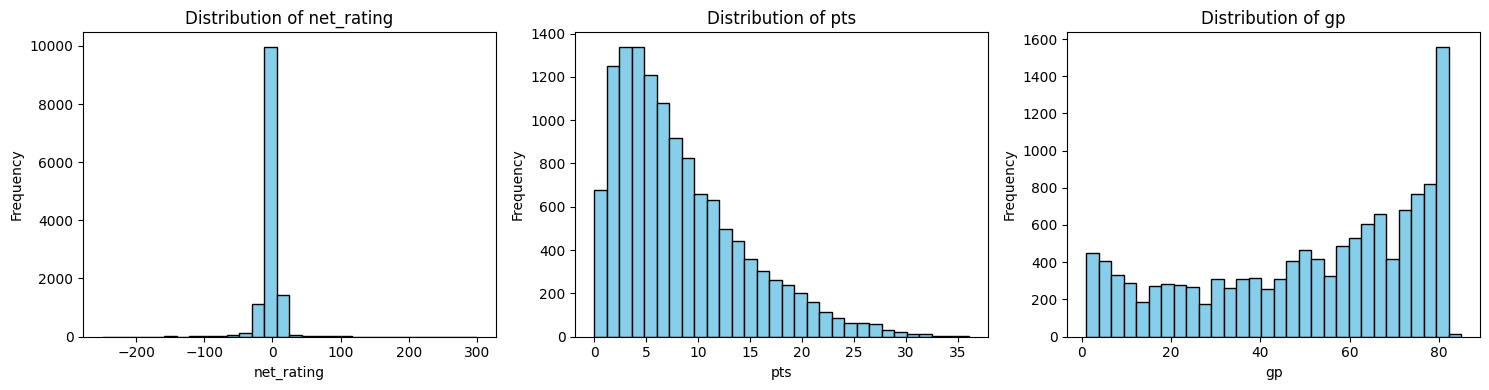

In [ ]:
check_distribution_code_writer = student_a

def check_distribution(df: pd.DataFrame) -> dict:
    """
    Here we inspect the distribution of our numeric values and check outliers with simple IQR 
    """
    numeric_cols = [
        "age",
        "player_height",
        "player_weight",
        "gp",
        "pts",
        "reb",
        "ast",
        "net_rating",
        "oreb_pct",
        "dreb_pct",
        "usg_pct",
        "ts_pct",
        "ast_pct",
    ]

    distribution_report = {}

    for col in numeric_cols:
        s = pd.to_numeric(df[col], errors='coerce')
        q = s.quantile([0.05, 0.25, 0.5, 0.75, 0.95])
        q05 = float(q.loc[0.05])
        q25 = float(q.loc[0.25])
        q50 = float(q.loc[0.5])
        q75 = float(q.loc[0.75])
        q95 = float(q.loc[0.95])
        iqr = q75 - q25

        lower = q25 - 1.5 * iqr
        upper = q75 + 1.5 * iqr
        n_outliers = int(((s < lower) | (s > upper)).sum())

        distribution_report[col] = {
            "count": int(s.shape[0]),
            "mean": float(s.mean()),
            "std": float(s.std(ddof=1)),
            "min": float(s.min()),
            "max": float(s.max()),
            "q05": q05,
            "q25": q25,
            "median": q50,
            "q75": q75,
            "q95": q95,
            "iqr": iqr,
            "lower_iqr_bound": float(lower),
            "upper_iqr_bound": float(upper),
            "n_outliers_iqr": n_outliers,
        }

    print("Numeric distributions")
    for col, stats in distribution_report.items():
        print(
            f"{col:15s} | mean={stats['mean']:.2f}, std={stats['std']:.2f}, "
            f"min={stats['min']:.2f}, max={stats['max']:.2f}, "
            f"outliers(IQR)={stats['n_outliers_iqr']}"
        )

    #we also want to plot some distributions, lets look at the ones that seem the most important
    cols_for_plot = ["net_rating","pts", "gp"]
    cols_for_plot = [c for c in cols_for_plot if c in df.columns]

    if cols_for_plot:
        fig, axes = plt.subplots(1, len(cols_for_plot), figsize=(5 * len(cols_for_plot), 4))
        if len(cols_for_plot) == 1:
            axes = [axes]
        for ax, col in zip(axes, cols_for_plot):
            ax.hist(df[col].dropna(), bins=30, color='skyblue', edgecolor='black')
            ax.set_title(f'Distribution of {col}')
            ax.set_xlabel(col)
            ax.set_ylabel('Frequency')
        plt.tight_layout()
        plt.show()
        return {"per_column": distribution_report}


start_time_dist = now()
dist_report = check_distribution(data)
end_time_dist = now()

dist_ass_uuid_executor = "6a7ba5e7-839f-439d-b68d-87b297df86b9"  # generate once and keep
check_distribution_executor = [
    f':check_distribution prov:qualifiedAssociation :{dist_ass_uuid_executor} .',
    f':{dist_ass_uuid_executor} prov:agent :{executed_by} .',
    f':{dist_ass_uuid_executor} rdf:type prov:Association .',
    f':{dist_ass_uuid_executor} prov:hadRole :{code_executor_role} .',
]
engine.insert(check_distribution_executor, prefixes=prefixes)

dist_ass_uuid_writer = "442db2ba-11c6-458a-adca-62e73480dc6a"  # generate once and keep
dist_comment = """
Here we inspect the distributions and plausible value ranges for the numeric NBA features by computing summary statistics for all of them
and by computing and IQR-based outlier range and count how many of the values fall out of this range. We also create some histograms 
for the most important attributes for visualization.
"""

dist_interpretation = """
The numeric distribution shows mostly plausible ranges for the biometric attributes but some of the performance metrics seem weird. They show 
heavy tails and many IRQ outliers, especially net_rating, ast, reb... This issue might arise as we also have players that only played very few games 
as we can see in the histogram and can therefore cause heavy skews. 
"""

check_distribution_activity = [
    # Activity node
    ':check_distribution rdf:type prov:Activity .',
    ':check_distribution sc:isPartOf :data_understanding_phase .',
    ":check_distribution rdfs:comment 'Data Understanding' .",
    f':check_distribution rdfs:comment """{dist_comment}""" .',
    f':check_distribution rdfs:comment """{dist_interpretation}""" .',
    f':check_distribution prov:startedAtTime "{start_time_dist}"^^xsd:dateTime .',
    f':check_distribution prov:endedAtTime "{end_time_dist}"^^xsd:dateTime .',

    # Code writer association
    f':check_distribution prov:qualifiedAssociation :{dist_ass_uuid_writer} .',
    f':{dist_ass_uuid_writer} prov:agent :{check_distribution_code_writer} .',
    f':{dist_ass_uuid_writer} rdf:type prov:Association .',
    f':{dist_ass_uuid_writer} prov:hadRole :{code_writer_role} .',

    # Input
    ':check_distribution prov:used :data .',

    # Output entity: numeric stats report
    ':du_numeric_stats rdf:type prov:Entity .',
    ':du_numeric_stats rdfs:label "Data Understanding: numeric distribution summary" .',
    f':du_numeric_stats rdfs:comment """{json.dumps(dist_report, indent=2)}""" .',
    ':du_numeric_stats prov:wasGeneratedBy :check_distribution .',
]

engine.insert(check_distribution_activity, prefixes=prefixes)

#put plot reference in Prov-O as well
fig_path = os.path.join("diagrams", "numerical_distribution.png").replace("\\", "/")
plot_entity_id = ":numeric_distribution"      
plot_label = "numeric distributions of core attributes" 
plot_comment = """
Shows the numeric distribution of some core attributes
"""

plot_triples = [
    f"{plot_entity_id} rdf:type prov:Entity .",
    f"{plot_entity_id} rdfs:label \"{plot_label}\" .",
    f"{plot_entity_id} rdfs:comment \"\"\"{plot_comment.strip()}\"\"\" .",
    f"{plot_entity_id} prov:wasGeneratedBy :check_distribution .",  # <-- your activity id
    f"{plot_entity_id} prov:wasDerivedFrom :data .",
]


plot_triples += [
     ":numeric_distribution_file rdf:type cr:FileObject .",
     ":numeric_distribution_file sc:name \"numerical_distribution.png\" .",
     ":numeric_distribution_file sc:encodingFormat \"image/png\" .",
     f":numeric_distribution_file sc:contentUrl \"{fig_path}\" .",
     f"{plot_entity_id} sc:distribution :numeric_distribution_file .",
 ]

engine.insert(plot_triples, prefixes=prefixes)

**Continue with other tasks of the Data Understanding phase such as checking the distribution, skewness, plausibility of values, etc...**

Categorical distributions
team_abbreviation  | unique=  36, missing=   0, top=[CLE (3.5%), TOR (3.5%), MIA (3.4%), DAL (3.4%), LAC (3.4%)]
college            | unique= 357, missing=1854, top=[NaN (14.4%), Kentucky (3.5%), Duke (3.2%), North Carolina (2.8%), UCLA (2.5%)]
country            | unique=  82, missing=   0, top=[USA (83.5%), Canada (1.6%), France (1.5%), Australia (0.8%), Spain (0.7%)]
draft_year         | unique=  48, missing=   0, top=[Undrafted (18.4%), 1998 (3.5%), 2003 (3.4%), 2005 (3.3%), 2008 (3.3%)]
draft_round        | unique=   9, missing=   0, top=[1 (57.2%), 2 (23.6%), Undrafted (18.8%), 3 (0.2%), 4 (0.1%)]
draft_number       | unique=  76, missing=   0, top=[Undrafted (18.8%), 1 (2.8%), 5 (2.8%), 4 (2.7%), 3 (2.6%)]
season             | unique=  27, missing=   0, top=[2021-22 (4.7%), 2017-18 (4.2%), 2020-21 (4.2%), 2022-23 (4.2%), 2018-19 (4.1%)]
player_name        | unique=2551, missing=   0, top=[Vince Carter (0.2%), Dirk Nowitzki (0.2%), Jamal Crawford (0.2%),

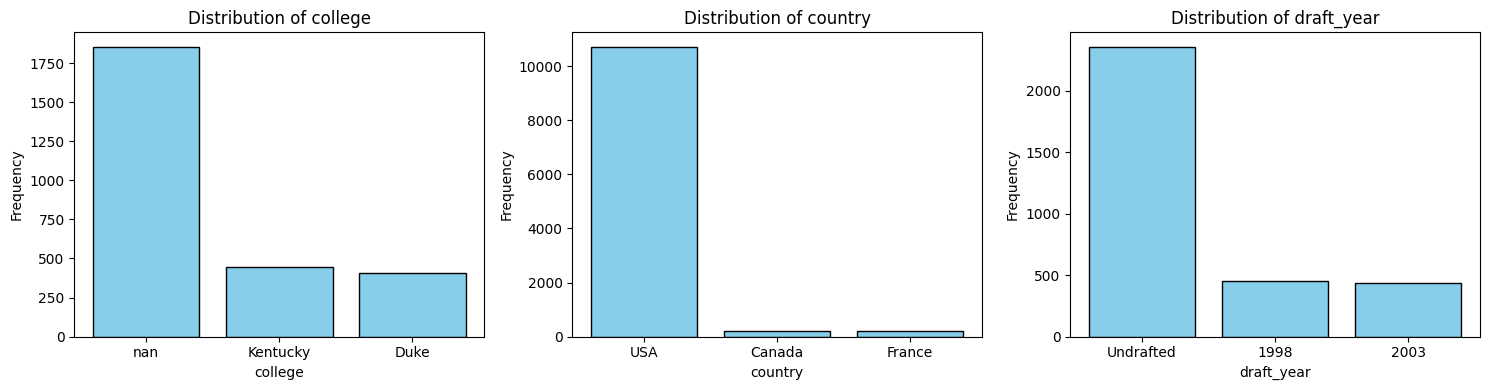

In [ ]:
check_categorical_distribution_code_writer = student_a

def check_categorical_distributions(df: pd.DataFrame) -> dict:
    """ Look at the distribution of categorical variables"""
    cat_cols = [
        "team_abbreviation",
        "college",
        "country",
        "draft_year",
        "draft_round",
        "draft_number",
        "season",
        "player_name",  
    ]

    report = {}
    n_rows = int(df.shape[0])
    for col in cat_cols:
        s = df[col]
        missing = int(s.isna().sum())
        value_counts = s.value_counts(dropna=False)
        n_unique = int(value_counts.shape[0])
        top_values = value_counts.head(5)
        top_list = [
            {"value": "NaN" if pd.isna(idx) else str(idx), "count": int(cnt), "freq": float(cnt / n_rows)}
            for idx, cnt in top_values.items()
        ]
        most_idx = top_values.index[0]
        most_val = "NaN" if pd.isna(most_idx) else str(most_idx)
        most_cnt = int(top_values.iloc[0])
        most_freq = float(most_cnt / n_rows)
        
        report[col] = {
            "n_rows": n_rows,
            "n_unique": n_unique,
            "n_missing": missing,
            "most_frequent_value": most_val,
            "most_frequent_count": most_cnt,
            "most_frequent_rel": most_freq,
            "top_values": top_list,
        }

        
    print("Categorical distributions")
    for col, stats in report.items():
            top_str = ", ".join([f"{x['value']} ({x['freq']*100:.1f}%)" for x in stats["top_values"]])
            print(
            f"{col:18s} | unique={stats['n_unique']:4d}, "
            f"missing={stats['n_missing']:4d}, top=[{top_str}]"
    )

    #bar plots for some categorical columns 
    cols_for_plot = ["college", "country", "draft_year"]
    cols_for_plot = [c for c in cols_for_plot if c in report]
    if cols_for_plot: 
        fig, axes = plt.subplots(1, len(cols_for_plot), figsize=(5 * len(cols_for_plot), 4))

        if len(cols_for_plot) == 1:
            axes = [axes]
        for ax, col in zip(axes, cols_for_plot):
            vc = df[col].value_counts(dropna=False).head(3)
            ax.bar([str(x) for x in vc.index], vc.values, color='skyblue', edgecolor='black'),
            ax.set_title(f'Distribution of {col}')
            ax.set_xlabel(col)
            ax.set_ylabel('Frequency')
        plt.tight_layout()
        plt.show()
        return {"per_column": report, "n_rows": n_rows}

start_time_cat = now()
cat_dist_report = check_categorical_distributions(data)
end_time_cat = now()

cat_ass_uuid_executor = "30ecfc19-ea1d-4400-863f-8e6ce6ce06b1"  # generate once, keep fixed
cat_executor_triples = [
    f":check_categorical_distributions prov:qualifiedAssociation :{cat_ass_uuid_executor} .",
    f":{cat_ass_uuid_executor} prov:agent :{executed_by} .",
    f":{cat_ass_uuid_executor} rdf:type prov:Association .",
    f":{cat_ass_uuid_executor} prov:hadRole :{code_executor_role} .",
]
engine.insert(cat_executor_triples, prefixes=prefixes)

cat_ass_uuid_writer = "ec9547af-df3e-4904-9b35-0885e03aa447"  # generate once, keep fixed
cat_comment = """
Compute the categorical frequency distributions for the categorical columns, generates report for the top-5 values per column and visulizes the top 3
for selected columns.
"""

interpret_cat = """
We see here that we have 36 different teams, 27 seasons and 2551 unique players. Country is heavily imbalanced towards the US. We have
the category "undrafted" in draftrounds and the college has some "nan" values which are just non-college players.
"""

cat_activity_triples = [
    # Activity
    ":check_categorical_distributions rdf:type prov:Activity .",
    ":check_categorical_distributions sc:isPartOf :data_understanding_phase .",
    ':check_categorical_distributions rdfs:comment "Data Understanding" .',
    f':check_categorical_distributions rdfs:comment """{cat_comment}""" .',
    f':check_categorical_distributions rdfs:comment """{interpret_cat}""" .',
    f':check_categorical_distributions prov:startedAtTime "{start_time_cat}"^^xsd:dateTime .',
    f':check_categorical_distributions prov:endedAtTime "{end_time_cat}"^^xsd:dateTime .',

    # Writer association (who wrote the code)
    f":check_categorical_distributions prov:qualifiedAssociation :{cat_ass_uuid_writer} .",
    f":{cat_ass_uuid_writer} prov:agent :{check_categorical_distribution_code_writer} .",
    f":{cat_ass_uuid_writer} rdf:type prov:Association .",
    f":{cat_ass_uuid_writer} prov:hadRole :{code_writer_role} .",

    # Inputs
    ":check_categorical_distributions prov:used :data .",

    # Output: report entity
    ":categorical_distribution_report rdf:type prov:Entity .",
    ':categorical_distribution_report rdfs:label "Categorical distribution report" .',
    f':categorical_distribution_report rdfs:comment """{json.dumps(cat_dist_report, indent=2)}""" .',
    ":categorical_distribution_report prov:wasGeneratedBy :check_categorical_distributions .",
    ":categorical_distribution_report prov:wasDerivedFrom :data .",

    # Output: plot entity (even if shown inline, still document it)
    ":categorical_distribution_plot rdf:type prov:Entity .",
    ':categorical_distribution_plot rdfs:label "Categorical distribution bar plots (top-3)" .',
    ':categorical_distribution_plot rdfs:comment "Matplotlib bar plots for college, country, draft_year (top-3 incl. NaN)." .',
    ":categorical_distribution_plot prov:wasGeneratedBy :check_categorical_distributions .",
    ":categorical_distribution_plot prov:wasDerivedFrom :data .",
]
engine.insert(cat_activity_triples, prefixes=prefixes)

#put plot reference in Prov-O as well
fig_path = os.path.join("diagrams", "Categorical_distribution.png").replace("\\", "/")
plot_entity_id = ":categoric_distribution"      
plot_label = "Categoric distributions of core attributes" 
plot_comment = """
Shows the categoric distribution of some core attributes
"""

plot_triples = [
    f"{plot_entity_id} rdf:type prov:Entity .",
    f"{plot_entity_id} rdfs:label \"{plot_label}\" .",
    f"{plot_entity_id} rdfs:comment \"\"\"{plot_comment.strip()}\"\"\" .",
    f"{plot_entity_id} prov:wasGeneratedBy :check_categorical_distributions .",  
    f"{plot_entity_id} prov:wasDerivedFrom :data .",
]


plot_triples += [
     ":categoric_distribution_file rdf:type cr:FileObject .",
     ":categoric_distribution_file sc:name \"Categorical_distribution.png\" .",
     ":categoric_distribution_file sc:encodingFormat \"image/png\" .",
     f":categoric_distribution_file sc:contentUrl \"{fig_path}\" .",
     f"{plot_entity_id} sc:distribution :categoric_distribution_file .",
 ]

engine.insert(plot_triples, prefixes=prefixes)


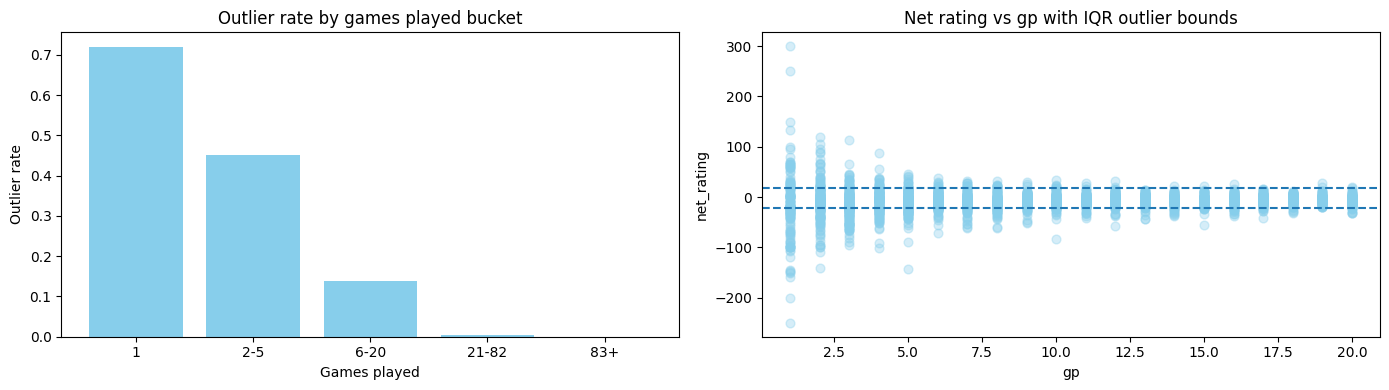

In [ ]:
hypothesis_checkcode_writer = student_a

def analyze_low_gp(df: pd.DataFrame) -> dict:
    """ We want to analyze if players with low games played are the reason for our outliers in the net_rating distribution"""


    tmp = df.copy()
    tmp["gp_num"] = pd.to_numeric(tmp["gp"], errors="coerce")
    tmp["net_rating_num"] = pd.to_numeric(tmp["net_rating"], errors="coerce")
    tmp = tmp.dropna(subset=["gp_num", "net_rating_num"])

    q25, q75 = tmp["net_rating_num"].quantile([0.25, 0.75])
    iqr = float(q75 - q25)
    lower = float(q25 - 1.5 * iqr)
    upper = float(q75 + 1.5 * iqr)

    tmp["is_outlier_iqr"] = (tmp["net_rating_num"] < lower) | (tmp["net_rating_num"] > upper)

    #bin the games played
    bins = [0, 1, 5, 20, 82, 10_000]
    labels = ["1", "2-5", "6-20", "21-82", "83+"]
    tmp["gp_bin"] = pd.cut(tmp["gp_num"], bins=bins, labels=labels, include_lowest=True)

    grp = (
        tmp.groupby("gp_bin", observed=True)
        .agg(n=("gp_num", "size"), outliers=("is_outlier_iqr", "sum"))
        .reset_index()
    )
    grp["outlier_rate"] = grp["outliers"] / grp["n"]

    low_gp = tmp[tmp["gp_num"] <= 5]
    high_gp = tmp[tmp["gp_num"] >= 20]

    low_rate = float(low_gp["is_outlier_iqr"].mean()) if low_gp.shape[0] else float("nan")
    high_rate = float(high_gp["is_outlier_iqr"].mean()) if high_gp.shape[0] else float("nan")

    extreme = tmp.loc[tmp["net_rating_num"].abs().nlargest(10).index, ["player_name", "season", "team_abbreviation", "gp_num", "net_rating_num"]]
    extreme = extreme.sort_values("net_rating_num", ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    
    axes[0].bar(grp["gp_bin"].astype(str), grp["outlier_rate"].values, color="skyblue")
    axes[0].set_title("Outlier rate by games played bucket")
    axes[0].set_xlabel("Games played")
    axes[0].set_ylabel("Outlier rate")

    
    tmp_small = tmp[tmp["gp_num"] <= 20]
    axes[1].scatter(tmp_small["gp_num"], tmp_small["net_rating_num"], alpha=0.35, s=40, color="skyblue")
    axes[1].axhline(lower, linestyle="--")
    axes[1].axhline(upper, linestyle="--")
    axes[1].set_title("Net rating vs gp with IQR outlier bounds")
    axes[1].set_xlabel("gp")
    axes[1].set_ylabel("net_rating")

    plt.tight_layout()
    plt.show()

    report = {
        "iqr_lower": lower,
        "iqr_upper": upper,
        "low_gp_n": int(low_gp.shape[0]),
        "high_gp_n": int(high_gp.shape[0]),
        "low_gp_outlier_rate": low_rate,
        "high_gp_outlier_rate": high_rate,
        "by_gp_bin": grp.to_dict(orient="records"),
        "top_abs_net_rating_rows": extreme.to_dict(orient="records"),
    }

    return report


start_time_hyp = now()
hyp_report = analyze_low_gp(data)
end_time_hyp = now()

# Executor association
hyp_ass_uuid_executor = "8b1e0c2f-4e53-4d0c-9d8a-0f2c1f9dd4c2"  # generate once
hyp_executor = [
    f":hypothesis_net_rating_low_gp prov:qualifiedAssociation :{hyp_ass_uuid_executor} .",
    f":{hyp_ass_uuid_executor} prov:agent :{executed_by} .",
    f":{hyp_ass_uuid_executor} rdf:type prov:Association .",
    f":{hyp_ass_uuid_executor} prov:hadRole :{code_executor_role} .",
]
engine.insert(hyp_executor, prefixes=prefixes)

hyp_ass_uuid_writer = "baf4c61b-08c6-4550-8c2b-73dc92b9aeaa"

hyp_description = "Here we tested they hypothesis whether the outliers in net_rating in our data mostly come from players that have a very low number of games"
hyp_interpretation = """The hypothesis was tested. Our graohs show that the outliers of net_rating are mostly driven by players with a low amount of games because 
these rate based metrics are very unstable for a small amount of games. We see that the outlier rate for players with 1-5 games is about 0.7% compared to less than 
0.05 % for players with more than 21 games. This is important information for future steps."""

hyp_activity = [
   ":hypothesis_net_rating_low_gp rdf:type prov:Activity .",
    ":hypothesis_net_rating_low_gp sc:isPartOf :data_understanding_phase .",
    ':hypothesis_net_rating_low_gp rdfs:comment "Data Understanding" .',
    f':hypothesis_net_rating_low_gp rdfs:comment """{hyp_description}""" .',
    f':hypothesis_net_rating_low_gp rdfs:comment """{hyp_interpretation}""" .',
    f':hypothesis_net_rating_low_gp prov:startedAtTime "{start_time_hyp}"^^xsd:dateTime .',
    f':hypothesis_net_rating_low_gp prov:endedAtTime "{end_time_hyp}"^^xsd:dateTime .',
    f":hypothesis_net_rating_low_gp prov:qualifiedAssociation :{hyp_ass_uuid_writer} .",
    f":{hyp_ass_uuid_writer} prov:agent :{hypothesis_checkcode_writer} .",
    f":{hyp_ass_uuid_writer} rdf:type prov:Association .",
    f":{hyp_ass_uuid_writer} prov:hadRole :{code_writer_role} .",

    # INPUT
    ":hypothesis_net_rating_low_gp prov:used :data .",
    ":data rdf:type prov:Entity .",

    # OUTPUT
    ":net_rating_low_gp_hypothesis_report rdf:type prov:Entity .",
    ":net_rating_low_gp_hypothesis_report prov:wasGeneratedBy :hypothesis_net_rating_low_gp .",
    ":net_rating_low_gp_hypothesis_report prov:wasDerivedFrom :data .",
]
engine.insert(hyp_activity, prefixes=prefixes)

#put plot reference in Prov-O as well
fig_path = os.path.join("diagrams", "Outliers.png").replace("\\", "/")
plot_entity_id = ":low_games"      
plot_label = "Detection of outliers with low games" 
plot_comment = """
Looks at data points with low games to potentially find outliers.
"""

plot_triples = [
    f"{plot_entity_id} rdf:type prov:Entity .",
    f"{plot_entity_id} rdfs:label \"{plot_label}\" .",
    f"{plot_entity_id} rdfs:comment \"\"\"{plot_comment.strip()}\"\"\" .",
    f"{plot_entity_id} prov:wasGeneratedBy :hypothesis_net_rating_low_gp .",  
    f"{plot_entity_id} prov:wasDerivedFrom :data .",
]


plot_triples += [
     ":low_games_file rdf:type cr:FileObject .",
     ":low_games_file sc:name \"Outliers.png\" .",
     ":low_games_file sc:encodingFormat \"image/png\" .",
     f":low_games_file sc:contentUrl \"{fig_path}\" .",
     f"{plot_entity_id} sc:distribution :low_games_file .",
 ]

engine.insert(plot_triples, prefixes=prefixes)


Top-10 absolute pearson correlations:
player_height vs player_weight: 0.822
ast          vs ast_pct     : 0.803
pts          vs ast         : 0.664
pts          vs usg_pct     : 0.641
pts          vs reb         : 0.625
player_height vs dreb_pct    : 0.614
reb          vs dreb_pct    : 0.612
player_height vs ast_pct     : -0.609
player_weight vs dreb_pct    : 0.606
player_weight vs oreb_pct    : 0.600


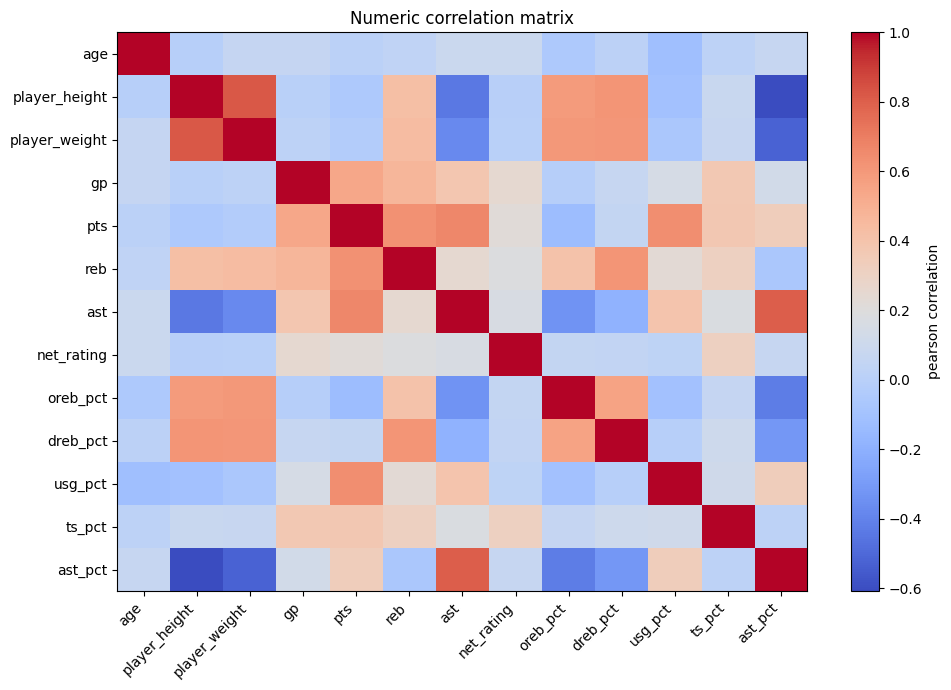

In [ ]:
check_correlations_code_writer = student_a
def check_correlations(df: pd.DataFrame, method: str = "pearson", top_k: int = 10) -> dict:
    numeric_cols = [
        "age", "player_height", "player_weight", "gp", "pts", "reb", "ast",
        "net_rating", "oreb_pct", "dreb_pct", "usg_pct", "ts_pct", "ast_pct"
    ]

    num = df[numeric_cols].apply(pd.to_numeric, errors="coerce")
    corr = num.corr(method=method)

    pairs = []
    cols = corr.columns.tolist()
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            a, b = cols[i], cols[j]
            val = corr.loc[a, b]
            if pd.notna(val):
                pairs.append({"a": a, "b": b, "corr": float(val), "abs": float(abs(val))})
    pairs_sorted = sorted(pairs, key=lambda x: x["abs"], reverse=True)[:top_k]

    print(f"Top-{top_k} absolute {method} correlations:")
    for p in pairs_sorted:
        print(f"{p['a']:12s} vs {p['b']:12s}: {p['corr']:.3f}")


    plt.figure(figsize=(10, 7))
    plt.imshow(corr, aspect="auto", cmap="coolwarm")
    plt.colorbar(label=f"{method} correlation")
    plt.xticks(range(len(cols)), cols, rotation=45, ha="right")
    plt.yticks(range(len(cols)), cols)
    plt.title("Numeric correlation matrix")
    plt.tight_layout()
    plt.show()

    return {"method": method, "top_pairs": pairs_sorted, "corr_matrix": corr.round(4).to_dict()}

start_time_corr = now()
corr_report = check_correlations(data, method="pearson", top_k=10)
end_time_corr = now()

corr_ass_uuid_executor = "ae70603c-05c3-4dfd-92ec-8857110fe0e6"
engine.insert([
    f":check_correlations prov:qualifiedAssociation :{corr_ass_uuid_executor} .",
    f":{corr_ass_uuid_executor} prov:agent :{executed_by} .",
    f":{corr_ass_uuid_executor} rdf:type prov:Association .",
    f":{corr_ass_uuid_executor} prov:hadRole :{code_executor_role} .",
], prefixes=prefixes)

corr_ass_uuid_writer = "e5ef3bf5-a7bf-42ba-bab1-eacbe516734f"
corr_comment = """
Computed Pearson correlation matrix for numeric attributes and extracted top absolute correlated attribute pairs.
Visualized the correlation matrix as a heatmap.
"""

corr_interpretation = """
There are strong positive correlations between player height and weight, points and assists etc. Suprisingly there is a high negative 
correlation between a players height and assists. The heatmap illustrates the specific correlations very well. 
"""

engine.insert([
    ":check_correlations rdf:type prov:Activity .",
    ":check_correlations sc:isPartOf :data_understanding_phase .",
    f':check_correlations rdfs:comment """{corr_comment}""" .',
    f':check_correlations rdfs:comment """{corr_interpretation}""" .',
    f':check_correlations prov:startedAtTime "{start_time_corr}"^^xsd:dateTime .',
    f':check_correlations prov:endedAtTime "{end_time_corr}"^^xsd:dateTime .',

    f":check_correlations prov:qualifiedAssociation :{corr_ass_uuid_writer} .",
    f":{corr_ass_uuid_writer} prov:agent :{check_correlations_code_writer} .",
    f":{corr_ass_uuid_writer} rdf:type prov:Association .",
    f":{corr_ass_uuid_writer} prov:hadRole :{code_writer_role} .",

    ":check_correlations prov:used :data .",

    ":correlation_report rdf:type prov:Entity .",
    ':correlation_report rdfs:label "Correlation analysis report" .',
    f':correlation_report rdfs:comment """{json.dumps(corr_report, indent=2)}""" .',
    ":correlation_report prov:wasGeneratedBy :check_correlations .",
    ":correlation_report prov:wasDerivedFrom :data .",

    ":correlation_heatmap_plot rdf:type prov:Entity .",
    ':correlation_heatmap_plot rdfs:label "Correlation heatmap plot" .',
    ":correlation_heatmap_plot prov:wasGeneratedBy :check_correlations .",
    ":correlation_heatmap_plot prov:wasDerivedFrom :data .",
], prefixes=prefixes)

#put plot reference in Prov-O as well
fig_path = os.path.join("diagrams", "Correlation_Matrix.png").replace("\\", "/")
plot_entity_id = ":Correlation"      
plot_label = "Correlation Matrix" 
plot_comment = """
Creates Correlation Matrix with numeric values 
"""

plot_triples = [
    f"{plot_entity_id} rdf:type prov:Entity .",
    f"{plot_entity_id} rdfs:label \"{plot_label}\" .",
    f"{plot_entity_id} rdfs:comment \"\"\"{plot_comment.strip()}\"\"\" .",
    f"{plot_entity_id} prov:wasGeneratedBy :check_correlations .",  
    f"{plot_entity_id} prov:wasDerivedFrom :data .",
]


plot_triples += [
     ":correlation_file rdf:type cr:FileObject .",
     ":correlation_file sc:name \"Correlation_Matrix.png\" .",
     ":correlation_file sc:encodingFormat \"image/png\" .",
     f":correlation_file sc:contentUrl \"{fig_path}\" .",
     f"{plot_entity_id} sc:distribution :correlation_file .",
 ]

engine.insert(plot_triples, prefixes=prefixes)

In [ ]:
ethics_comment = """
Ethical Check. 
There are several things that have to be minded when dealing with this dataset when it comes to ethical concerns.
There are no explicit sensitive attributes but some attributes can still act as proxies: 
- country: this is not necessarily nationality but correlates strongly with a players origin and their ethnic background and may be used to infer 
sensitive characteristics
- college: this encodes the education pathway and may give hints about socioeconomic differences and scouting pipelines
- player_height, player_weight: the distribution is obviously heavily skewed towards large and heavy players, as this is beneficial for baskteball
These biometric attributes may enable stereotyping or discrimination as well.
- player_name: although these players are public figues, the names still personally identify them and have to be handled responsibly 

Underrepresented groups:
- due to the nature of basketball, tiny people and lightweight people are underrepresented in this dataset
- country is heavily imbalanced towards USA players, meaning non-USA players are a minority group in this data representation
- college has a substantial NaN fraction, which likely reflects alternative pathways 

For further evaluation we have to mind that we should not only meassure performance overall across groups but also within groups (USA vs non-USA etc.) to detect potential bias.
"""

triples_e = [
    ":data_understanding_ethics rdf:type sc:CreativeWork .",
    ":data_understanding_ethics sc:isPartOf :data_understanding_phase .",
    f':data_understanding_ethics rdfs:comment """{ethics_comment}""" .',
]
engine.insert(triples_e, prefixes=prefixes)

In [ ]:
bias_risk_comment = """
Potential Biases and Risks includ the following:
- Selection Bias: This dataset only contains players that actually made it to the NBA, which is a highly selective group.
- Time Bias: the overall game of basketball evolved over time (for example 3 point shooting increased alot) so relationships between metrics across seasons are hard to interpret.
- Low sample size for some groups: (international players, undrafted players) can lead to unreliable statistics for these groups
- Players with low games: have heavy skews in rate based metrics (net_rating etc.) which can distort analysis if not handled properly

Questions for Expert:
- Exact calculation of our measurements? Is garbage time included? Is it comparable to other calculation methods? 
- What if players are traded mid season? Is that represented as two separate entries or one?
- Are there any known data quality issues with the source data? Is missing college truly just non-college players?
"""

triples_f = [
    ":data_understanding_bias_risks rdf:type sc:CreativeWork .",
    ":data_understanding_bias_risks sc:isPartOf :data_understanding_phase .",
    f':data_understanding_bias_risks rdfs:comment """{bias_risk_comment}""" .',
]
engine.insert(triples_f, prefixes=prefixes)



In [ ]:
prep_actions_comment = """
Here are some potential data preparation actions based on the data understanding phase:
- handle low games played: 
    - filter out players with very low games played as they lead to unstable metrics
    - filter out players with gp under a certain number (e.g. under 20) or weighting by gp

- remove non-informative technical columns 
    - droop unnamed_0 column

- handle categorical variables:
    - one-hot encode team_abbreviation, college, country, draft_year, draft_round, draft_number
    - consider embedding for player_name if used

- mind that players can appear across seasons:
    - player_name + season forms a composite key, avoid putting to much weight on one player alone 

- scaling of numeric variables:
    - standard scaling or min-max scaling for numeric variables like age, player_height

- handle missing data
    - as the missing rows in college are likely non-college players, we can impute them with a special category no_college
"""

triples_g = [
    ":data_understanding_prep_actions rdf:type sc:CreativeWork .",
    ":data_understanding_prep_actions sc:isPartOf :data_understanding_phase .",
    f':data_understanding_prep_actions rdfs:comment """{prep_actions_comment}""" .',
]
engine.insert(triples_g, prefixes=prefixes)

## Data Preparation

In [ ]:
## Each Activity that follows is part of the Data Preparation Phase

data_preparation_phase_executor = [
f':data_preparation_phase rdf:type prov:Activity .',
f':data_preparation_phase rdfs:label "Data Preparation Phase" .', 
]
engine.insert(data_preparation_phase_executor, prefixes=prefixes)

In [ ]:
data_prep_code_writer = student_b

def preprocess_nba(df: pd.DataFrame, gp_min: int = 6) -> pd.DataFrame:
    out = df.copy()
    out = out.drop(columns=["Unnamed: 0"], errors="ignore")

    out["college"] = out["college"].fillna("no_college")

    out["gp"] = pd.to_numeric(out["gp"], errors="coerce")
    out = out.dropna(subset=["gp"])
    out = out[out["gp"] >= gp_min]

    out["season_start"] = out["season"].astype(str).str.slice(0, 4).astype(int)

    for c in ["draft_year", "draft_round", "draft_number"]:
        out[c] = out[c].fillna("undrafted").astype(str).str.strip()
        out[c] = out[c].replace({"Undrafted":"undrafted", "nan":"undrafted", "None":"undrafted"})

    return out

start_time_dp = now()
cleaned = preprocess_nba(data, gp_min=6)
end_time_dp = now()
cleaned.info()

dp_ass_uuid_exec = "0b248020-487d-484f-8b3f-8132e323af88"
dp_ass_uuid_writer = "77e7ab42-d7be-42e8-b4d9-02049e60728b"

dp_preprocess_comment = """
1.removed technical index column 'Unnamed: 0';
2.imputed missing college values (NaN) with category 'no_college';
3. mitigated unstable extreme net_rating values caused by very low games played by filtering to gp >= 6 (parameter gp_min=6);
4. parsed season strings into season_start (int) to enable time-aware splitting later;
5/ normalized draft_year/draft_round/draft_number as categorical strings, mapping missing/Undrafted to 'undrafted'.
Output datasets: :cleaned_data (row-filtered + imputed) derived from :data.
"""

triples = [
  ":preprocess_nba rdf:type prov:Activity .",
  ":preprocess_nba sc:isPartOf :data_preparation_phase .",
  f':preprocess_nba rdfs:comment """{dp_preprocess_comment}""" .',
  f':preprocess_nba prov:startedAtTime "{start_time_dp}"^^xsd:dateTime .',
  f':preprocess_nba prov:endedAtTime "{end_time_dp}"^^xsd:dateTime .',

  f":preprocess_nba prov:qualifiedAssociation :{dp_ass_uuid_exec} .",
  f":{dp_ass_uuid_exec} prov:agent :{executed_by} .",
  f":{dp_ass_uuid_exec} prov:hadRole :{code_executor_role} .",
  f":{dp_ass_uuid_exec} rdf:type prov:Association .",

  f":preprocess_nba prov:qualifiedAssociation :{dp_ass_uuid_writer} .",
  f":{dp_ass_uuid_writer} prov:agent :{data_prep_code_writer} .",
  f":{dp_ass_uuid_writer} prov:hadRole :{code_writer_role} .",
  f":{dp_ass_uuid_writer} rdf:type prov:Association .",

  ":preprocess_nba prov:used :data .",

  ":cleaned_data rdf:type prov:Entity .",
  ":cleaned_data rdf:type sc:Dataset .",
  ":cleaned_data prov:wasGeneratedBy :preprocess_nba .",
  ":cleaned_data prov:wasDerivedFrom :data .",
]
engine.insert(triples, prefixes=prefixes)


<class 'pandas.core.frame.DataFrame'>
Index: 12119 entries, 0 to 12843
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   player_name        12119 non-null  object 
 1   team_abbreviation  12119 non-null  object 
 2   age                12119 non-null  float64
 3   player_height      12119 non-null  float64
 4   player_weight      12119 non-null  float64
 5   college            12119 non-null  object 
 6   country            12119 non-null  object 
 7   draft_year         12119 non-null  object 
 8   draft_round        12119 non-null  object 
 9   draft_number       12119 non-null  object 
 10  gp                 12119 non-null  int64  
 11  pts                12119 non-null  float64
 12  reb                12119 non-null  float64
 13  ast                12119 non-null  float64
 14  net_rating         12119 non-null  float64
 15  oreb_pct           12119 non-null  float64
 16  dreb_pct           12119 no

In [ ]:
dp_not_applied_code_writer = student_b

start_time_dp3b = now()
end_time_dp3b = now()


dp3b_ass_uuid_executor = "819688ad-4c18-450d-9ecf-8b4ab30ebc8b"  
dp3b_ass_uuid_writer   = "4b883758-ffbe-4415-b8c8-0c1e9194678d"    

dp_not_applied_comment = """
(3b) Considered but not applied preprocessing:
- Full outlier removal / IQR trimming on net_rating: not applied because extreme net_rating values can be valid. main driver were very low games played and we handled this via gp filtering instead (avoids removing informative rare cases).
- clipping of net_rating: not applied to keep target interpretation unchanged.
- Stronger gp threshold (e.g., gp>=20): considered, but rejected to avoid losing too many players/seasons and biasing towards starters only.
- Scaling/normalization of numeric features: deferred because planned models can handle different scales (or scaling can be done inside the modeling pipeline if needed).
- Binning (age/height/weight): not applied to avoid information loss and arbitrary cutoffs.
- Using player_name as feature: not applied to reduce memorization/ID leakage. name kept only as identifier.
- One-hot encoding of categorical variables: not done as a standalone data-prep step. will be handled in the modeling pipeline.
"""
dp3b_triples = [
    # Activity
    ":document_dp_not_applied rdf:type prov:Activity .",
    ":document_dp_not_applied sc:isPartOf :data_preparation_phase .",
    ':document_dp_not_applied rdfs:label "3b Preprocessing considered but not applied"@en .',
    f':document_dp_not_applied rdfs:comment """{dp_not_applied_comment}""" .',
    f':document_dp_not_applied prov:startedAtTime "{start_time_dp3b}"^^xsd:dateTime .',
    f':document_dp_not_applied prov:endedAtTime "{end_time_dp3b}"^^xsd:dateTime .',

    # Executor association 
    f":document_dp_not_applied prov:qualifiedAssociation :{dp3b_ass_uuid_executor} .",
    f":{dp3b_ass_uuid_executor} prov:agent :{executed_by} .",
    f":{dp3b_ass_uuid_executor} rdf:type prov:Association .",
    f":{dp3b_ass_uuid_executor} prov:hadRole :{code_executor_role} .",

    # Writer association 
    f":document_dp_not_applied prov:qualifiedAssociation :{dp3b_ass_uuid_writer} .",
    f":{dp3b_ass_uuid_writer} prov:agent :{dp_not_applied_code_writer} .",
    f":{dp3b_ass_uuid_writer} rdf:type prov:Association .",
    f":{dp3b_ass_uuid_writer} prov:hadRole :{code_writer_role} .",

    ":document_dp_not_applied prov:used :du_overview .",
    ":document_dp_not_applied prov:used :du_numeric_stats .",
    ":document_dp_not_applied prov:used :net_rating_low_gp_hypothesis_report .",
]

engine.insert(dp3b_triples, prefixes=prefixes)

dp3b_report_triples = [
    ":dp_not_applied_report rdf:type prov:Entity .",
    ':dp_not_applied_report rdfs:label "3b Not applied preprocessing (report)"@en .',
    f':dp_not_applied_report rdfs:comment """{dp_not_applied_comment}""" .',
    ":dp_not_applied_report prov:wasGeneratedBy :document_dp_not_applied .",
]
engine.insert(dp3b_report_triples, prefixes=prefixes)

In [ ]:
dp_derived_code_writer = student_b

def add_derived_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    out["season_start"] = out["season"].astype(str).str.slice(0, 4).astype(int)

    out["player_height"] = pd.to_numeric(out["player_height"], errors="coerce")
    out["player_weight"] = pd.to_numeric(out["player_weight"], errors="coerce")
    out["height_m"] = out["player_height"] / 100.0
    out["bmi"] = out["player_weight"] / (out["height_m"] ** 2)

    out["gp"] = pd.to_numeric(out["gp"], errors="coerce")
    for c in ["pts", "reb", "ast"]:
        out[c] = pd.to_numeric(out[c], errors="coerce")

    out["pts_per_gp"] = out["pts"] / out["gp"]
    out["reb_per_gp"] = out["reb"] / out["gp"]
    out["ast_per_gp"] = out["ast"] / out["gp"]

    # draft_year can be 'undrafted' (string) -> numeric coercion gives NaN
    out["draft_year_num"] = pd.to_numeric(out["draft_year"], errors="coerce")
    out["drafted_flag"] = out["draft_year_num"].notna()
    out["experience_years"] = out["season_start"] - out["draft_year_num"]

    return out

start_time_dp3c = now()
prepared = add_derived_features(cleaned) 
end_time_dp3c = now()

prepared.info()

dp3c_ass_uuid_executor = "aee9df86-3d59-4841-a317-74162466b07b"
dp3c_ass_uuid_writer   = "074f1268-aac6-4010-a07d-9f9fa11339bf"

dp_derived_attrs_comment = """
Derived attributes created (feature engineering):
- season_start (int): parsed from season (e.g., '2019-20' -> 2019) for time-aware evaluation.
- height_m: player_height / 100.
- bmi: player_weight / (height_m^2) to capture body composition.
- pts_per_gp, reb_per_gp, ast_per_gp: per-game normalization of box-score stats.
- drafted_flag: True if draft_year is known, else False ('undrafted').
- experience_years: season_start - draft_year (NaN if undrafted).
These derived attributes support more stable and comparable modeling features.
"""

dp3c_triples = [
    ":feature_engineering rdf:type prov:Activity .",
    ":feature_engineering sc:isPartOf :data_preparation_phase .",
    ':feature_engineering rdfs:label "3c Derived attributes / feature engineering"@en .',
    f':feature_engineering rdfs:comment """{dp_derived_attrs_comment}""" .',
    f':feature_engineering prov:startedAtTime "{start_time_dp3c}"^^xsd:dateTime .',
    f':feature_engineering prov:endedAtTime "{end_time_dp3c}"^^xsd:dateTime .',

    f":feature_engineering prov:qualifiedAssociation :{dp3c_ass_uuid_executor} .",
    f":{dp3c_ass_uuid_executor} prov:agent :{executed_by} .",
    f":{dp3c_ass_uuid_executor} rdf:type prov:Association .",
    f":{dp3c_ass_uuid_executor} prov:hadRole :{code_executor_role} .",

    f":feature_engineering prov:qualifiedAssociation :{dp3c_ass_uuid_writer} .",
    f":{dp3c_ass_uuid_writer} prov:agent :{dp_derived_code_writer} .",
    f":{dp3c_ass_uuid_writer} rdf:type prov:Association .",
    f":{dp3c_ass_uuid_writer} prov:hadRole :{code_writer_role} .",

    ":feature_engineering prov:used :cleaned_data .",

    ":prepared_data rdf:type prov:Entity .",
    ":prepared_data rdf:type sc:Dataset .",
    ":prepared_data prov:wasGeneratedBy :feature_engineering .",
    ":prepared_data prov:wasDerivedFrom :cleaned_data .",
]

engine.insert(dp3c_triples, prefixes=prefixes)

<class 'pandas.core.frame.DataFrame'>
Index: 12119 entries, 0 to 12843
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   player_name        12119 non-null  object 
 1   team_abbreviation  12119 non-null  object 
 2   age                12119 non-null  float64
 3   player_height      12119 non-null  float64
 4   player_weight      12119 non-null  float64
 5   college            12119 non-null  object 
 6   country            12119 non-null  object 
 7   draft_year         12119 non-null  object 
 8   draft_round        12119 non-null  object 
 9   draft_number       12119 non-null  object 
 10  gp                 12119 non-null  int64  
 11  pts                12119 non-null  float64
 12  reb                12119 non-null  float64
 13  ast                12119 non-null  float64
 14  net_rating         12119 non-null  float64
 15  oreb_pct           12119 non-null  float64
 16  dreb_pct           12119 no

In [ ]:
dp_external_code_writer = student_b

dp_external_data_comment = """
External data sources:
We did not integrate external datasets in this assignment submission.

External sources that could improve the model :
- Salary / contract / cap hit data (to identify undervalued players).
- Minutes / possessions / lineup context (to stabilize impact metrics).
- Injury history / availability.
- Team strength / coaching / role indicators.
- Additional advanced metrics (e.g WS, BPM, RAPM/RAPTOR-type metrics) or tracking stats.

Reasons for not using external data:
- availability/licensing and time constraints,
- matching keys and season alignment complexity,
- risk of data leakage if future-season information is accidentally included.
"""

start_time_dp3d = now()
end_time_dp3d = now()


dp3d_ass_uuid_executor = "2b429d4b-e12c-4949-9b9b-a45fb53c64d6"
dp3d_ass_uuid_writer   = "7ddf9980-9ae0-426e-a3e1-515c0a86e4e1"

dp3d_triples = [
    # Activity
    ":document_external_data rdf:type prov:Activity .",
    ":document_external_data sc:isPartOf :data_preparation_phase .",
    ':document_external_data rdfs:label "3d External data sources (not integrated)"@en .',
    f':document_external_data rdfs:comment """{dp_external_data_comment}""" .',
    f':document_external_data prov:startedAtTime "{start_time_dp3d}"^^xsd:dateTime .',
    f':document_external_data prov:endedAtTime "{end_time_dp3d}"^^xsd:dateTime .',

    
    f":document_external_data prov:qualifiedAssociation :{dp3d_ass_uuid_executor} .",
    f":{dp3d_ass_uuid_executor} prov:agent :{executed_by} .",
    f":{dp3d_ass_uuid_executor} rdf:type prov:Association .",
    f":{dp3d_ass_uuid_executor} prov:hadRole :{code_executor_role} .",

    # Writer association
    f":document_external_data prov:qualifiedAssociation :{dp3d_ass_uuid_writer} .",
    f":{dp3d_ass_uuid_writer} prov:agent :{dp_external_code_writer} .",
    f":{dp3d_ass_uuid_writer} rdf:type prov:Association .",
    f":{dp3d_ass_uuid_writer} prov:hadRole :{code_writer_role} .",

    ":document_external_data prov:used :data .",
    ":document_external_data prov:used :cleaned_data .",
    ":document_external_data prov:used :prepared_data .",
]

engine.insert(dp3d_triples, prefixes=prefixes)


In [ ]:
prepared_data_triples = [
    ':prepared rdf:type prov:Entity .',
    ':prepared prov:wasDerivedFrom :cleaned_data .',
    ':prepared rdf:type sc:Dataset .',
]
engine.insert(prepared_data_triples, prefixes=prefixes)

## Modeling

In [ ]:
# Each Activity that follows is part of the Modeling Phase

modeling_phase_executor = [
f':modeling_phase rdf:type prov:Activity .',
f':modeling rdfs:label "Modeling Phase" .', 
]
engine.insert(modeling_phase_executor, prefixes=prefixes)


In [ ]:
model_data_code_writer = student_a
#
###############################################
### Documentation 4a
###############################################

dma_ass_uuid_writer = "6e74378d-59d6-4f0c-a999-ccd6adc03579"

dma_comment = """
As this is a regression task we will consider the following models: 

Baseline:
-here we just predict the mean for all samples
-acts just as a baseline and not the actual model 

Linear Regression (Ordinary Least Squares):
-very simple model that is fast to implement and very easy to interpret
-the simplicity also leads to struggles with mutlicollinearity and limitations when it comes to nonlinearity

Elastic Net Regression (L1 + L2 regularization):
-this method handles mutlticollinearity better than normal OLS 
-it also shrinks features that are irrelevant and therefore is more stable 
-the features are still linear, so we would need to choose the regularization strength

3) Random Forest Regression:
-can model nonlinear relationships without manual feature engeineering
-genereally very robust and well performign for tabular data
-adaptable parameters 
-though less interpretable than linear models and can overfit if not tuned properly

We select the Random Forest as the most suitable model for our experiments.
We expect nonlinear relationships in the data and want a model that can handle this in a robust way.
Random Forests are a good off-the-shelf model for tabular data and should perform well here. The model
also has easily interpretable hyperparameters that we can tune and has built-in feature importance measures.

"""
identify_data_mining_algorithm_activity = [
    f':define_algorithm rdf:type prov:Activity .',
    f':define_algorithm sc:isPartOf :modeling_phase .',
    f':define_algorithm rdfs:comment """{dma_comment}""" .',
    f':define_algorithm prov:qualifiedAssociation :{dma_ass_uuid_writer} .',
    f':{dma_ass_uuid_writer} prov:agent :{model_data_code_writer} .',
    f':{dma_ass_uuid_writer} rdf:type prov:Association .',
    f':{dma_ass_uuid_writer} prov:hadRole :{code_writer_role} .',

    f':random_forest_regression_algorithm rdf:type mls:Algorithm .',
    f':random_forest_regression_algorithm rdfs:label "Random Forest Regression" .',

    #implementation
    f':sklearn_random_forest_regressor_impl rdf:type mls:Implementation .',
    f':sklearn_random_forest_regressor_impl rdfs:label "scikit-learn RandomForestRegressor" .',
    f':sklearn_random_forest_regressor_impl mls:implements :random_forest_regression_algorithm .',
    f':sklearn_random_forest_regressor_impl prov:wasGeneratedBy :define_algorithm .',

    
    #evaluation measures
    f':rmse_measure rdf:type mls:EvaluationMeasure .',
    f':rmse_measure rdfs:label "RMSE" .',
    f':rmse_measure rdfs:comment "Root mean squared error" .',
    f':rmse_measure prov:wasGeneratedBy :define_algorithm .',

    f':mae_measure rdf:type mls:EvaluationMeasure .',
    f':mae_measure rdfs:label "MAE" .',
    f':mae_measure rdfs:comment "Mean absolute error" .',
    f':mae_measure prov:wasGeneratedBy :define_algorithm .',

    f':r2_measure rdf:type mls:EvaluationMeasure .',
    f':r2_measure rdfs:label "R2" .',
    f':r2_measure rdfs:comment "Coefficient of determination, describes explained variance" .',
    f':r2_measure prov:wasGeneratedBy :define_algorithm .',
  
]
engine.insert(identify_data_mining_algorithm_activity, prefixes=prefixes)

In [ ]:
#############################################
# Documentation 4b
#############################################

hp_ass_uuid_writer = "bb98baa3-fc43-471d-ac6e-0082ce7c36a7"
hp_comment = """
We chose the Random Forest and are going to use the implementation by scikit-learn.

Some of the available hyperparameters are: 
-n_estimators: number of trees 
-max_depth: maximum depth of the trees
-min_samples_split: minimum samples required to split a node
-min_samples_leaf: minimum samples required at a leaf node
-max_features: number of features to consider when looking for the best split
-bootstrap: whether bootstrap samples are used when building trees

From the ones above we choose max_depth for tuning:
The max_depth directly controls overfitting vs underfitting, has obvious interpretation and is a key parameter for Random Forest.
It is also easy to tune reproducibly and easy to understand its effects. 
We are going to use the following parameters 
max_depth(2,5,10,16, None)
"""

identify_hp_activity = [
    f':identify_hyperparameters rdf:type prov:Activity .',
    f':identify_hyperparameters sc:isPartOf :modeling_phase .',
    f':identify_hyperparameters rdfs:comment """{hp_comment}""" .',
    f':identify_hyperparameters prov:qualifiedAssociation :{hp_ass_uuid_writer} .',
    f':{hp_ass_uuid_writer} prov:agent :{model_data_code_writer} .',
    f':{hp_ass_uuid_writer} rdf:type prov:Association .',
    f':{hp_ass_uuid_writer} prov:hadRole :{code_writer_role} .',
    
    f':hp_n_estimators rdf:type mls:HyperParameter .',
    f':hp_n_estimators rdfs:label \"n_estimators\" .',
    f':hp_n_estimators rdfs:comment \"Number of trees in the forest\" .',
    f':sklearn_random_forest_regressor_impl mls:hasHyperParameter :hp_n_estimators .',
    f':hp_n_estimators prov:wasGeneratedBy :identify_hyperparameters .',

    f':hp_max_depth rdf:type mls:HyperParameter .',
    f':hp_max_depth rdfs:label \"max_depth\" .',
    f':hp_max_depth rdfs:comment \"Maximum depth of each decision tree\" .',
    f':sklearn_random_forest_regressor_impl mls:hasHyperParameter :hp_max_depth .',
    f':hp_max_depth prov:wasGeneratedBy :identify_hyperparameters .',
    f':hp_min_samples_split rdf:type mls:HyperParameter .',

    f':hp_min_samples_split rdfs:label \"min_samples_split\" .',
    f':hp_min_samples_split rdfs:comment \"Minimum number of samples required to split an internal node\" .',
    f':sklearn_random_forest_regressor_impl mls:hasHyperParameter :hp_min_samples_split .',
    f':hp_min_samples_split prov:wasGeneratedBy :identify_hyperparameters .',

    f':hp_min_samples_leaf rdf:type mls:HyperParameter .',
    f':hp_min_samples_leaf rdfs:label \"min_samples_leaf\" .',
    f':hp_min_samples_leaf rdfs:comment \"Minimum number of samples required in a leaf node\" .',
    f':sklearn_random_forest_regressor_impl mls:hasHyperParameter :hp_min_samples_leaf .',
    f':hp_min_samples_leaf prov:wasGeneratedBy :identify_hyperparameters .',

    f':hp_max_features rdf:type mls:HyperParameter .',
    f':hp_max_features rdfs:label \"max_features\" .',
    f':hp_max_features rdfs:comment \"Number of features considered for each split.\" .',
    f':sklearn_random_forest_regressor_impl mls:hasHyperParameter :hp_max_features .',
    f':hp_max_features prov:wasGeneratedBy :identify_hyperparameters .',

    f':hp_bootstrap rdf:type mls:HyperParameter .',
    f':hp_bootstrap rdfs:label \"bootstrap\" .',
    f':hp_bootstrap rdfs:comment \"Whether bootstrap samples are used when building trees.\" .',
    f':sklearn_random_forest_regressor_impl mls:hasHyperParameter :hp_bootstrap .',
    f':hp_bootstrap prov:wasGeneratedBy :identify_hyperparameters .',

    
]
engine.insert(identify_hp_activity, prefixes=prefixes)

In [ ]:
#we will do time based splitting because of the seasonality of the data
#we will use two seaasons each for validation and testing, as we want to perform predictions for the "next season" we will use all previous seasons for training
def season_start_year(season_str: str) -> int:

    return int(str(season_str).split("-")[0])


def split_data(df: pd.DataFrame, n_test_seasons = 2, n_val_seasons = 2):
    df = df.copy()
    df["season_start"] = df["season"].apply(season_start_year)

    years = sorted(df["season_start"].dropna().unique().tolist())

    test_years = years[-n_test_seasons:]
    val_years = years[-(n_val_seasons + n_test_seasons):-n_test_seasons]
    train_years = years[:-(n_val_seasons + n_test_seasons)]

    train_df = df[df["season_start"].isin(train_years)].copy()
    val_df = df[df["season_start"].isin(val_years)].copy()
    test_df = df[df["season_start"].isin(test_years)].copy()

    split_info = {
        "split_type": "time_based_by_season_start",
        "train_years": train_years,
        "val_years": val_years,
        "test_years": test_years,
        "n_train": int(train_df.shape[0]),
        "n_val": int(val_df.shape[0]),
        "n_test": int(test_df.shape[0]),
    }
    return train_df, val_df, test_df, split_info



#############################################
# Documentation 4c
#############################################
input_dataset = ":prepared_data"

start_time_split = now()
train_df, val_df, test_df, split_info = split_data(prepared, n_val_seasons=2, n_test_seasons=2)
end_time_split = now()

print("Split info:", split_info)



### Define Train/Validation/Test splits
split_ass_uuid_writer = "d2af993e-34fe-4d5b-bf47-bed621c63dfc"
split_ass_uuid_executor = "4e28e22a-3d8b-4f4f-8ef5-2c8c4c1f2c9a" 
split_comment = f"""
Here we define a reproducible split. We use a time-based strategy by season to avoid look-ahead leakage.
In basketball trends change over time and random splitting would leak future-season patterns into the training set. 
As we want to predict the feature for the future seasons, it only makes sense to split the time like that and 
not let the model see data from the test and validation seasons. We know that this may lead to worse measures 
but they will be more realistic. 

Split rule:
- Training seasons: all seasons with start year in {split_info["train_years"]}
- Validation seasons: next {len(split_info["val_years"])} seasons with start year in {split_info["val_years"]}
- Test seasons: most recent {len(split_info["test_years"])} seasons with start year in {split_info["test_years"]}

Resulting sizes:
- Training set: {split_info["n_train"]} rows
- Validation set: {split_info["n_val"]} rows
- Test set: {split_info["n_test"]} rows
 """

input_dataset = ":prepared_data" 



define_split_activity = [
    f':define_data_split rdf:type prov:Activity .',
    f':define_data_split sc:isPartOf :modeling_phase .',
    f':define_data_split rdfs:comment "Train/Validation/Test Split Definition" .',
    f':define_data_split rdfs:comment """{split_comment}""" .',
    f":define_data_split prov:startedAtTime \"{start_time_split}\"^^xsd:dateTime .",
    f":define_data_split prov:endedAtTime \"{end_time_split}\"^^xsd:dateTime .",




    f':define_data_split prov:qualifiedAssociation :{split_ass_uuid_writer} .',
    f':{split_ass_uuid_writer} prov:agent :{model_data_code_writer} .',
    f':{split_ass_uuid_writer} rdf:type prov:Association .',
    f':{split_ass_uuid_writer} prov:hadRole :{code_writer_role} .',
    f':define_data_split prov:used {input_dataset} .',

    f":define_data_split prov:qualifiedAssociation :{split_ass_uuid_executor} .",
    f":{split_ass_uuid_executor} prov:agent :{executed_by} .",
    f":{split_ass_uuid_executor} rdf:type prov:Association .",
    f":{split_ass_uuid_executor} prov:hadRole :{code_executor_role} .",
    

    # input dataset
    f":define_data_split prov:used {input_dataset} .",

    # Validation Set
    f':validation_set rdf:type sc:Dataset .',
    f':validation_set rdfs:label "Validation Set" .',
    f':validation_set prov:wasGeneratedBy :define_data_split .',
    f':validation_set prov:wasDerivedFrom {input_dataset} .',
    f':validation_set rdfs:comment "Contains xx samples" .', 

    # Training Set
    ":training_set rdf:type sc:Dataset .",
    ":training_set rdfs:label \"Training Set\" .",
    ":training_set prov:wasGeneratedBy :define_data_split .",
    f":training_set prov:wasDerivedFrom {input_dataset} .",
    f":training_set rdfs:comment \"Contains {split_info['n_train']} rows\" .",

    # Validation Set
    ":validation_set rdf:type sc:Dataset .",
    ":validation_set rdfs:label \"Validation Set\" .",
    ":validation_set prov:wasGeneratedBy :define_data_split .",
    f":validation_set prov:wasDerivedFrom {input_dataset} .",
    f":validation_set rdfs:comment \"Contains {split_info['n_val']} rows\" .",

    # Test Set
    ":test_set rdf:type sc:Dataset .",
    ":test_set rdfs:label \"Test Set\" .",
    ":test_set prov:wasGeneratedBy :define_data_split .",
    f":test_set prov:wasDerivedFrom {input_dataset} .",
    f":test_set rdfs:comment \"Contains {split_info['n_test']} rows\" .",

    # split config as an entity for reproducibility
    ":split_config rdf:type prov:Entity .",
    ":split_config rdfs:label \"Split configuration (4c)\" .",
    f":split_config rdfs:comment \"\"\"{json.dumps(split_info, indent=2)}\"\"\" .",
    ":split_config prov:wasGeneratedBy :define_data_split .",

    
]



engine.insert(define_split_activity, prefixes=prefixes)

Split info: {'split_type': 'time_based_by_season_start', 'train_years': [1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018], 'val_years': [2019, 2020], 'test_years': [2021, 2022], 'n_train': 10098, 'n_val': 997, 'n_test': 1024}


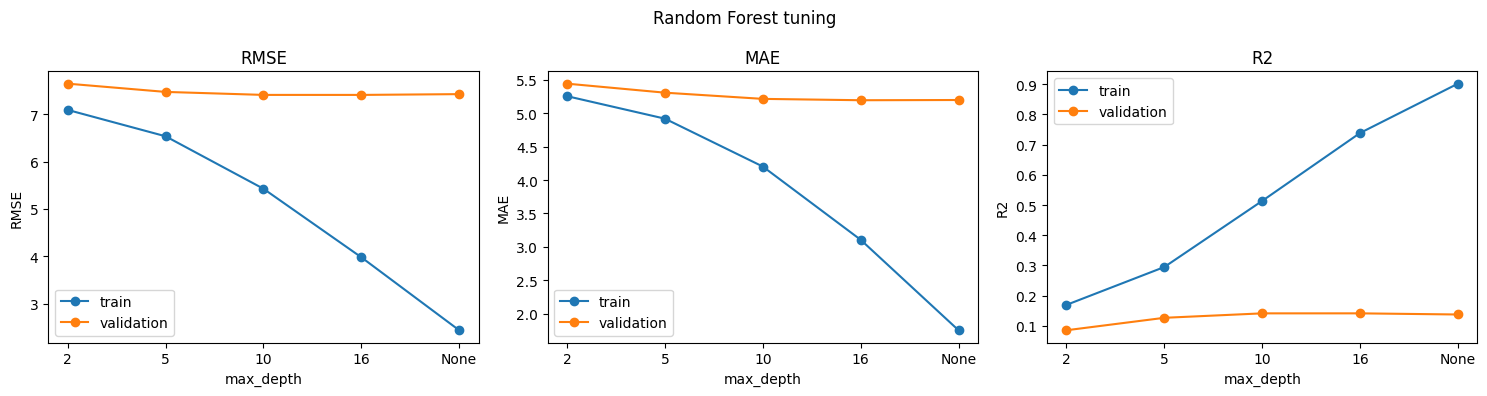

Best max_depth: 16.0
  max_depth_label  train_rmse  val_rmse  train_mae   val_mae  train_r2  \
0              16    3.977430  7.406508   3.106720  5.194394  0.738573   
1              10    5.424873  7.406651   4.202245  5.214612  0.513677   
2            None    2.436018  7.422937   1.753407  5.197704  0.901937   
3               5    6.532761  7.469901   4.918444  5.307403  0.294756   
4               2    7.089662  7.644132   5.254945  5.442234  0.169390   

     val_r2  
0  0.141312  
1  0.141279  
2  0.137498  
3  0.126550  
4  0.085329  


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

def train_and_finetune_model(training_set, validation_set):
    TARGET_COL = "net_rating"
    drop_cols = [TARGET_COL, "player_name", "season", "season_start"]

    
    

    X_train = training_set.drop(columns=[c for c in drop_cols if c in training_set.columns], errors="ignore")
    y_train = training_set[TARGET_COL].astype(float).values

    X_val = validation_set.drop(columns=[c for c in drop_cols if c in validation_set.columns], errors="ignore")
    y_val = validation_set[TARGET_COL].astype(float).values

    #convert booleans
    bool_cols = [c for c in X_train.columns if str(X_train[c].dtype) == "bool"]
    for c in bool_cols:
        X_train[c] = X_train[c].astype(int)
        X_val[c] = X_val[c].astype(int)

    cat_cols = [c for c in X_train.columns if X_train[c].dtype == "object"]
    num_cols = [c for c in X_train.columns if c not in cat_cols]


    preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))]), num_cols),
            ("cat", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]), cat_cols),
        ],
        remainder="drop",
    )
    fixed_params = {
        "n_estimators": 300,
        "random_state": 61,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
        "max_features": 1.0,
        "bootstrap": True,
        "n_jobs": -1,
    }

    depth_grid = [2, 5, 10, 16, None]

    results = []
    models = {}   


    for depth in depth_grid:
        rf = RandomForestRegressor(max_depth=depth, **fixed_params)

        model = Pipeline(steps=[
            ("prep", preprocessor),
            ("rf", rf),
        ])

        model.fit(X_train, y_train)

        pred_train = model.predict(X_train)
        pred_val = model.predict(X_val)

        train_rmse = float(np.sqrt(mean_squared_error(y_train, pred_train)))
        val_rmse = float(np.sqrt(mean_squared_error(y_val, pred_val)))

        train_mae = float(mean_absolute_error(y_train, pred_train))
        val_mae = float(mean_absolute_error(y_val, pred_val))

        train_r2 = float(r2_score(y_train, pred_train))
        val_r2 = float(r2_score(y_val, pred_val))

        depth_label = "None" if depth is None else str(depth)

        results.append({
            "max_depth": depth,
            "max_depth_label": depth_label,
            "train_rmse": train_rmse,
            "val_rmse": val_rmse,
            "train_mae": train_mae,
            "val_mae": val_mae,
            "train_r2": train_r2,
            "val_r2": val_r2,
        })

        models[depth_label] = model 


    results_df = pd.DataFrame(results).sort_values("val_rmse", ascending=True).reset_index(drop=True)
    best_depth = results_df.loc[0, "max_depth"]
    best_depth_label = results_df.loc[0, "max_depth_label"]
    best_model = models[best_depth_label]


    os.makedirs("diagrams", exist_ok=True)
    plot_path = os.path.join("diagrams", "rf_tuning_max_depth.png")
    plot_df = pd.DataFrame(results).copy()
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)

    # RMSE
    axes[0].plot(plot_df["max_depth_label"], plot_df["train_rmse"], marker="o", label="train")
    axes[0].plot(plot_df["max_depth_label"], plot_df["val_rmse"], marker="o", label="validation")
    axes[0].set_title("RMSE")
    axes[0].set_ylabel("RMSE")

    # MAE
    axes[1].plot(plot_df["max_depth_label"], plot_df["train_mae"], marker="o", label="train")
    axes[1].plot(plot_df["max_depth_label"], plot_df["val_mae"], marker="o", label="validation")
    axes[1].set_title("MAE")
    axes[1].set_ylabel("MAE")

    # R2
    axes[2].plot(plot_df["max_depth_label"], plot_df["train_r2"], marker="o", label="train")
    axes[2].plot(plot_df["max_depth_label"], plot_df["val_r2"], marker="o", label="validation")
    axes[2].set_title("R2")
    axes[2].set_ylabel("R2")

    for ax in axes:
        ax.set_xlabel("max_depth")
        ax.legend()

    plt.suptitle("Random Forest tuning")
    plt.tight_layout()
    plt.savefig(plot_path, dpi=150)
    plt.show()


    return best_model, results_df, best_depth, plot_path, fixed_params, depth_grid

start_time_tafm = now()
best_model, tuning_results_df, best_depth, tuning_fig_path, fixed_params, depth_grid = train_and_finetune_model(train_df, val_df)
end_time_tafm = now()

print("Best max_depth:", best_depth)
print(tuning_results_df[[
    "max_depth_label",
    "train_rmse", "val_rmse",
    "train_mae", "val_mae",
    "train_r2", "val_r2"
]])


#############################################
# Documentation 4d & e & f
#############################################

tafm_ass_uuid_writer = "d2af993e-34fe-4d5b-bf47-bed621c63dfc"
tafm_ass_uuid_executor = "1832d307-1c6d-42d2-a8ab-12c88b8536ae"

best_depth_label = "None" if best_depth is None else str(best_depth)

tafm_comment = f"""
Here we trained the Random Forest Regressor on the training set and tuned only the max_depth with the possibilities: 2, 5, 10, 16, None on the validation set. 
We fixed the other parameters explicitly and then choose the model with the lowest validation RMSE. The selected best max_depth is {best_depth_label}.
"""




triples = [
    ":train_and_finetune_model rdf:type prov:Activity .",
    ":train_and_finetune_model sc:isPartOf :modeling_phase .",
    f":train_and_finetune_model rdfs:comment \"\"\"{tafm_comment.strip()}\"\"\" .",
    f":train_and_finetune_model prov:startedAtTime \"{start_time_tafm}\"^^xsd:dateTime .",
    f":train_and_finetune_model prov:endedAtTime \"{end_time_tafm}\"^^xsd:dateTime .",

    f":train_and_finetune_model prov:qualifiedAssociation :{tafm_ass_uuid_writer} .",
    f":{tafm_ass_uuid_writer} prov:agent :{model_data_code_writer} .",
    f":{tafm_ass_uuid_writer} rdf:type prov:Association .",
    f":{tafm_ass_uuid_writer} prov:hadRole :{code_writer_role} .",

    f":train_and_finetune_model prov:qualifiedAssociation :{tafm_ass_uuid_executor} .",
    f":{tafm_ass_uuid_executor} prov:agent :{executed_by} .",
    f":{tafm_ass_uuid_executor} rdf:type prov:Association .",
    f":{tafm_ass_uuid_executor} prov:hadRole :{code_executor_role} .",

    # inputs
    ":train_and_finetune_model prov:used :training_set .",
    ":train_and_finetune_model prov:used :validation_set .",

    ":rf_tuning_results rdf:type prov:Entity .",
    ":rf_tuning_results rdfs:label \"RF tuning results (max_depth grid)\" .",
    f":rf_tuning_results rdfs:comment \"\"\"{tuning_results_df.to_json(orient='records', indent=2)}\"\"\" .",
    ":rf_tuning_results prov:wasGeneratedBy :train_and_finetune_model .",
]


fig_path_kg = tuning_fig_path.replace("\\", "/")
triples += [
    ":rf_tuning_plot rdf:type prov:Entity .",
    ":rf_tuning_plot rdfs:label \"RF tuning curve (max_depth vs RMSE)\" .",
    ":rf_tuning_plot rdfs:comment \"Saved plot of RMSE on train and validation for each max_depth.\" .",
    ":rf_tuning_plot prov:wasGeneratedBy :train_and_finetune_model .",

    ":rf_tuning_plot_file rdf:type cr:FileObject .",
    ":rf_tuning_plot_file sc:name \"rf_tuning_max_depth.png\" .",
    ":rf_tuning_plot_file sc:encodingFormat \"image/png\" .",
    f":rf_tuning_plot_file sc:contentUrl \"{fig_path_kg}\" .",
    ":rf_tuning_plot sc:distribution :rf_tuning_plot_file .",
]

for _, row in tuning_results_df.iterrows():
    depth_label = row["max_depth_label"]

    run_id = f":rf_run_depth_{depth_label}"
    model_id = f":rf_model_depth_{depth_label}"
    hp_setting_id = f":hp_setting_max_depth_{depth_label}"

    eval_train_rmse_id = f":rf_eval_train_rmse_depth_{depth_label}"
    eval_val_rmse_id = f":rf_eval_val_rmse_depth_{depth_label}"

    eval_train_mae_id = f":rf_eval_train_mae_depth_{depth_label}"
    eval_val_mae_id = f":rf_eval_val_mae_depth_{depth_label}"

    eval_train_r2_id = f":rf_eval_train_r2_depth_{depth_label}"
    eval_val_r2_id = f":rf_eval_val_r2_depth_{depth_label}"

    triples += [
        #hyperparameter setting
        f"{hp_setting_id} rdf:type mls:HyperParameterSetting .",
        f"{hp_setting_id} mls:specifiedBy :hp_max_depth .",
        f"{hp_setting_id} mls:hasValue \"{depth_label}\" .",
        f"{hp_setting_id} prov:wasGeneratedBy :train_and_finetune_model .",

        #run
        f"{run_id} rdf:type mls:Run .",
        f"{run_id} sc:isPartOf :train_and_finetune_model .",
        f"{run_id} mls:realizes :random_forest_regression_algorithm .",
        f"{run_id} rdfs:label \"RF run with max_depth={depth_label}\" .",
        f"{run_id} mls:executes :sklearn_random_forest_regressor_impl .",
        f"{run_id} mls:hasInput :training_set .",
        f"{run_id} mls:hasInput :validation_set .",
        f"{run_id} mls:hasInput {hp_setting_id} .",
        f"{run_id} mls:hasOutput {model_id} .",

        #model
        f"{model_id} rdf:type mls:Model .",
        f"{model_id} rdfs:label \"Trained RF model (max_depth={depth_label})\" .",
        f"{model_id} prov:wasGeneratedBy {run_id} .",
        f"{model_id} mlso:trainedOn :training_set .",
        f"{model_id} mlso:hasAlgorithmType :random_forest_regression_algorithm .",

        #evaluations: RMSE
        f"{eval_train_rmse_id} rdf:type mls:ModelEvaluation .",
        f"{eval_train_rmse_id} prov:wasGeneratedBy {run_id} .",
        f"{eval_train_rmse_id} mls:specifiedBy :rmse_measure .",
        f"{eval_train_rmse_id} mls:hasValue \"{float(row['train_rmse'])}\"^^xsd:double .",
        f"{eval_train_rmse_id} prov:used :training_set .",

        f"{eval_val_rmse_id} rdf:type mls:ModelEvaluation .",
        f"{eval_val_rmse_id} prov:wasGeneratedBy {run_id} .",
        f"{eval_val_rmse_id} mls:specifiedBy :rmse_measure .",
        f"{eval_val_rmse_id} mls:hasValue \"{float(row['val_rmse'])}\"^^xsd:double .",
        f"{eval_val_rmse_id} prov:used :validation_set .",

        #evaluations: MAE
        f"{eval_train_mae_id} rdf:type mls:ModelEvaluation .",
        f"{eval_train_mae_id} prov:wasGeneratedBy {run_id} .",
        f"{eval_train_mae_id} mls:specifiedBy :mae_measure .",
        f"{eval_train_mae_id} mls:hasValue \"{float(row['train_mae'])}\"^^xsd:double .",
        f"{eval_train_mae_id} prov:used :training_set .",

        f"{eval_val_mae_id} rdf:type mls:ModelEvaluation .",
        f"{eval_val_mae_id} prov:wasGeneratedBy {run_id} .",
        f"{eval_val_mae_id} mls:specifiedBy :mae_measure .",
        f"{eval_val_mae_id} mls:hasValue \"{float(row['val_mae'])}\"^^xsd:double .",
        f"{eval_val_mae_id} prov:used :validation_set .",

        #evaluations: R2
        f"{eval_train_r2_id} rdf:type mls:ModelEvaluation .",
        f"{eval_train_r2_id} prov:wasGeneratedBy {run_id} .",
        f"{eval_train_r2_id} mls:specifiedBy :r2_measure .",
        f"{eval_train_r2_id} mls:hasValue \"{float(row['train_r2'])}\"^^xsd:double .",
        f"{eval_train_r2_id} prov:used :training_set .",

        f"{eval_val_r2_id} rdf:type mls:ModelEvaluation .",
        f"{eval_val_r2_id} prov:wasGeneratedBy {run_id} .",
        f"{eval_val_r2_id} mls:specifiedBy :r2_measure .",
        f"{eval_val_r2_id} mls:hasValue \"{float(row['val_r2'])}\"^^xsd:double .",
        f"{eval_val_r2_id} prov:used :validation_set .",
    ]

    run_config_id = f":rf_config_depth_{depth_label}"
    all_params = fixed_params.copy()
    all_params["max_depth"] = None if depth_label == "None" else int(depth_label)

    triples += [
        f"{run_config_id} rdf:type prov:Entity .",
        f"{run_config_id} rdfs:label \"RF config (max_depth={depth_label})\" .",
        f"{run_config_id} rdfs:comment \"\"\"{json.dumps(all_params, indent=2)}\"\"\" .",
        f"{run_config_id} prov:wasGeneratedBy :train_and_finetune_model .",
        f"{run_id} mls:hasInput {run_config_id} .",
        ]

#Best model decision entity (4f)
triples += [
    ":selected_model rdf:type prov:Entity .",
    ":selected_model rdfs:label \"Selected model after validation (4f)\" .",
    f":selected_model rdfs:comment \"Selected max_depth={best_depth_label} based on lowest validation RMSE.\" .",
    ":selected_model prov:wasGeneratedBy :train_and_finetune_model .",
    f":selected_model prov:wasDerivedFrom :rf_model_depth_{best_depth_label} .",
]

engine.insert(triples, prefixes=prefixes)


In [ ]:
def retrain_model_full_data(training_set, validation_set, best_depth, fixed_params):
    TARGET_COL = "net_rating"

    trainval_df = pd.concat([training_set, validation_set], axis=0, ignore_index=True)
    drop_cols = [TARGET_COL, "player_name", "season", "season_start"]
    X = trainval_df.drop(columns=[c for c in drop_cols if c in trainval_df.columns], errors="ignore").copy()
    y = trainval_df[TARGET_COL].astype(float).values

    bool_cols = [c for c in X.columns if str(X[c].dtype) == "bool"]
    for c in bool_cols:
        X[c] = X[c].astype(int)

    cat_cols = [c for c in X.columns if X[c].dtype == "object"]
    num_cols = [c for c in X.columns if c not in cat_cols]

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))]), num_cols),
            ("cat", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]), cat_cols),
        ],
        remainder="drop",
    )

    if best_depth is None:
        depth = None
        best_depth_label = "None"
    else:
        depth = int(best_depth)
        best_depth_label = str(depth)

    rf = RandomForestRegressor(max_depth=depth, **fixed_params)

    final_model = Pipeline(steps=[
        ("prep", preprocessor),
        ("rf", rf),
    ])

    final_model.fit(X, y)

    pred = final_model.predict(X)
    metrics_trainval = {
        "rmse": float(np.sqrt(mean_squared_error(y, pred))),
        "mae": float(mean_absolute_error(y, pred)),
        "r2": float(r2_score(y, pred)),
    }

    return final_model, best_depth_label, trainval_df.shape[0], metrics_trainval

start_time_retrain = now()
final_model, best_depth_label, n_trainval, metrics_trainval = retrain_model_full_data(
    train_df, val_df, best_depth, fixed_params
)
end_time_retrain = now()

print("Final model retrained on train+val")
print("Used max_depth:", best_depth_label)
print("Train+Val sanity:", metrics_trainval)


#############################################
# Documentation 4g
#############################################

retrain_ass_uuid_writer = "53c18d15-b76e-48fe-8432-00535143189a"
retrain_ass_uuid_executor = "0f3a8b3f-7e13-4c1b-9b10-6a8d4bd1f9d1"
 # Generate once
final_params = fixed_params.copy()
final_params["max_depth"] = None if best_depth_label == "None" else int(best_depth_label)

retrain_comment = f"""
Here we retrained final RandomForestRegressor on full training+validation data using identical hyperparameters from tuning.
Selected max_depth={best_depth_label}.
Train+Val sanity metrics: {metrics_trainval}.
"""


triples_4g = [
    ":retrain_final_model rdf:type prov:Activity .",
    ":retrain_final_model sc:isPartOf :modeling_phase .",
    f":retrain_final_model rdfs:comment \"\"\"{retrain_comment.strip()}\"\"\" .",
    f":retrain_final_model prov:startedAtTime \"{start_time_retrain}\"^^xsd:dateTime .",
    f":retrain_final_model prov:endedAtTime \"{end_time_retrain}\"^^xsd:dateTime .",

    f":retrain_final_model prov:qualifiedAssociation :{retrain_ass_uuid_writer} .",
    f":{retrain_ass_uuid_writer} prov:agent :{model_data_code_writer} .",
    f":{retrain_ass_uuid_writer} rdf:type prov:Association .",
    f":{retrain_ass_uuid_writer} prov:hadRole :{code_writer_role} .",

    f":retrain_final_model prov:qualifiedAssociation :{retrain_ass_uuid_executor} .",
    f":{retrain_ass_uuid_executor} prov:agent :{executed_by} .",
    f":{retrain_ass_uuid_executor} rdf:type prov:Association .",
    f":{retrain_ass_uuid_executor} prov:hadRole :{code_executor_role} .",

    ":retrain_final_model prov:used :training_set .",
    ":retrain_final_model prov:used :validation_set .",

    ":train_validation_set rdf:type sc:Dataset .",
    f":train_validation_set rdfs:comment \"Contains {int(n_trainval)} samples.\" .",
    ":train_validation_set prov:wasGeneratedBy :retrain_final_model .",
    ":train_validation_set prov:wasDerivedFrom :training_set .",
    ":train_validation_set prov:wasDerivedFrom :validation_set .",

    ":final_rf_config rdf:type prov:Entity .",
    ":finalg:final_rf_config rdfs:label \"Final RF parameter config\" .".replace(":G:", ":"), 
    f":final_rf_config rdfs:comment \"\"\"{json.dumps(final_params, indent=2)}\"\"\" .",
    ":final_rf_config prov:wasGeneratedBy :retrain_final_model .",

    ":final_rf_model rdf:type mls:Model .",
    f":final_rf_model rdfs:label \"Final RF model (max_depth={best_depth_label})\" .",
    ":final_rf_model prov:wasGeneratedBy :retrain_final_model .",
    ":final_rf_model mlso:trainedOn :train_validation_set .",
    ":final_rf_model mlso:hasAlgorithmType :random_forest_regression_algorithm .",
    ":final_rf_model prov:wasDerivedFrom :final_rf_config .",
]

engine.insert(triples_4g, prefixes=prefixes)


Final model retrained on train+val
Used max_depth: 16
Train+Val sanity: {'rmse': 4.164994602444249, 'mae': 3.216143427559644, 'r2': 0.7147915306080643}


## Evaluation

In [ ]:
## Each Activity that follows is part of the Evaluation Phase

evaluation_phase_executor = [
f':evaluation_phase rdf:type prov:Activity .',
f':evaluation_phase rdfs:label "Evaluation Phase" .', 
]
engine.insert(evaluation_phase_executor, prefixes=prefixes)

In [ ]:
eval_code_writer = student_b

# ===============================
# Step 5a 
# ===============================

def evaluate_on_test_data(model, test_set):
    TARGET_COL = "net_rating"
    drop_cols = [TARGET_COL, "player_name", "season", "season_start"]

    X_test = test_set.drop(columns=[c for c in drop_cols if c in test_set.columns], errors="ignore")
    y_test = test_set[TARGET_COL].astype(float).values

    bool_cols = [c for c in X_test.columns if str(X_test[c].dtype) == "bool"]
    for c in bool_cols:
        X_test[c] = X_test[c].astype(int)

    y_pred = model.predict(X_test)

    rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
    mae  = float(mean_absolute_error(y_test, y_pred))
    r2   = float(r2_score(y_test, y_pred))
    return rmse, mae, r2

start_time_eval = now()
test_rmse, test_mae, test_r2 = evaluate_on_test_data(final_model, test_df)
end_time_eval = now()
print("RMSE:", test_rmse)
print("MAE:", test_mae)
print("r2:", test_r2)


In [ ]:

# ===============================
# Documentation / Provenance
# ===============================

eval_ass_uuid_writer = "76da29ca-8106-4489-964f-db263e13ea1f"
eval_ass_uuid_executor = "PUT-ANOTHER-UUID-HERE"   # generate once

final_model_uri = ":final_rf_model"
test_set_uri = ":test_set"

eval_comment = f"""
Evaluation of the final Random Forest regression model on the held-out test set.

Results:
- RMSE: {test_rmse:.4f}
- MAE:  {test_mae:.4f}
- R²:   {test_r2:.4f}

Interpretation:
Test performance is comparable to validation performance, suggesting stable generalization.
RMSE and MAE quantify average prediction error in net_rating units; R² indicates explained variance.
These results will be compared to baseline and (if available) external benchmarks in 5b/5c.
Bias evaluation is performed in 5e.
"""

evaluate_activity = [
    ":evaluate_final_model rdf:type prov:Activity .",
    ":evaluate_final_model sc:isPartOf :evaluation_phase .",
    ":evaluate_final_model rdfs:label \"Final Model Evaluation on Test Set\" .",
    f":evaluate_final_model rdfs:comment \"\"\"{eval_comment.strip()}\"\"\" .",
    f":evaluate_final_model prov:startedAtTime \"{start_time_eval}\"^^xsd:dateTime .",
    f":evaluate_final_model prov:endedAtTime \"{end_time_eval}\"^^xsd:dateTime .",

    # writer association
    f":evaluate_final_model prov:qualifiedAssociation :{eval_ass_uuid_writer} .",
    f":{eval_ass_uuid_writer} prov:agent :{eval_code_writer} .",
    f":{eval_ass_uuid_writer} rdf:type prov:Association .",
    f":{eval_ass_uuid_writer} prov:hadRole :{code_writer_role} .",

    # executor association 
    f":evaluate_final_model prov:qualifiedAssociation :{eval_ass_uuid_executor} .",
    f":{eval_ass_uuid_executor} prov:agent :{executed_by} .",
    f":{eval_ass_uuid_executor} rdf:type prov:Association .",
    f":{eval_ass_uuid_executor} prov:hadRole :{code_executor_role} .",

    # Inputs
    f":evaluate_final_model prov:used {final_model_uri} .",
    f":evaluate_final_model prov:used {test_set_uri} .",
    ":evaluate_final_model prov:used :bu_data_mining_success_criteria .",

    # Output
    ":rf_test_metrics rdf:type prov:Entity .",
    ":rf_test_metrics rdfs:label \"Final Model Test Metrics\" .",
    f":rf_test_metrics rdfs:comment \"\"\"RMSE={test_rmse:.4f}, MAE={test_mae:.4f}, R2={test_r2:.4f}\"\"\" .",
    ":rf_test_metrics prov:wasGeneratedBy :evaluate_final_model .",


]

engine.insert(evaluate_activity, prefixes=prefixes)


In [ ]:
start_time_5bi = now()
end_time_5bi = now()

ass_uuid_5bi_writer = "4b8aae92-f849-466f-8cf6-a32a56b472f9"
ass_uuid_5bi_executor = "d5de86d3-8c36-418a-98d7-79a0011297ee"

comment_5bi = """
5b(i) State-of-the-art / benchmark search:

We searched for published benchmark performance for predicting net_rating (regression) on the same
NBA player-season dataset used in this project. We did not find peer-reviewed papers or stable online
benchmarks that report RMSE/MAE/R² for net_rating on this exact dataset and task.

As allowed by the assignment when no task-specific benchmark exists, we reference related public Kaggle
analyses that use NBA player/season data, but solve different ML problems and therefore are not directly
comparable as performance baselines for our regression task:

- "NBA game prediction using machine learning" (Kaggle): supervised classification task (game outcome),
  reports accuracy (~0.56) with cross-validated hyperparameter tuning for a tree-based gradient boosting
  model. Different target and metric → not comparable to our RMSE/MAE/R² regression evaluation.

- "Salary Cluster Analysis of NBA players" (Kaggle): unsupervised clustering analysis of NBA players and
  salary/performance attributes. No predictive regression target → no RMSE/MAE/R² baseline.

Therefore, quantitative comparison in this project relies on internally computed trivial baselines
(DummyRegressor mean/median and random baseline) in 5b(ii) and compared to our final model in 5c.
""".strip()

triples_5bi = [
    ":benchmark_search_5bi rdf:type prov:Activity .",
    ":benchmark_search_5bi sc:isPartOf :evaluation_phase .",
    ":benchmark_search_5bi rdfs:label \"Benchmark / SOTA search (5b-i)\" .",
    f":benchmark_search_5bi rdfs:comment \"\"\"{comment_5bi}\"\"\" .",
    f":benchmark_search_5bi prov:startedAtTime \"{start_time_5bi}\"^^xsd:dateTime .",
    f":benchmark_search_5bi prov:endedAtTime \"{end_time_5bi}\"^^xsd:dateTime .",
 
    # writer
    f":benchmark_search_5bi prov:qualifiedAssociation :{ass_uuid_5bi_writer} .",
    f":{ass_uuid_5bi_writer} prov:agent :{student_b} .",
    f":{ass_uuid_5bi_writer} rdf:type prov:Association .",
    f":{ass_uuid_5bi_writer} prov:hadRole :{code_writer_role} .",

    # executor
    f":benchmark_search_5bi prov:qualifiedAssociation :{ass_uuid_5bi_executor} .",
    f":{ass_uuid_5bi_executor} prov:agent :{executed_by} .",
    f":{ass_uuid_5bi_executor} rdf:type prov:Association .",
    f":{ass_uuid_5bi_executor} prov:hadRole :{code_executor_role} .",
]

engine.insert(triples_5bi, prefixes=prefixes)


In [ ]:
from sklearn.dummy import DummyRegressor

TARGET_COL = "net_rating"

# Use train+val distribution as baseline reference
trainval_df = pd.concat([train_df, val_df], ignore_index=True)
y_trainval = trainval_df[TARGET_COL].astype(float).values
y_test = test_df[TARGET_COL].astype(float).values

def reg_metrics(y_true, y_pred):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    r2   = float(r2_score(y_true, y_pred))
    return rmse, mae, r2

start_time_5bii = now()
# Baseline 1: mean predictor
dummy_mean = DummyRegressor(strategy="mean")
dummy_mean.fit(np.zeros((len(y_trainval), 1)), y_trainval)
pred_mean = dummy_mean.predict(np.zeros((len(y_test), 1)))
rmse_mean, mae_mean, r2_mean = reg_metrics(y_test, pred_mean)

# Baseline 2: median predictor
dummy_median = DummyRegressor(strategy="median")
dummy_median.fit(np.zeros((len(y_trainval), 1)), y_trainval)
pred_median = dummy_median.predict(np.zeros((len(y_test), 1)))
rmse_med, mae_med, r2_med = reg_metrics(y_test, pred_median)

# Baseline 3: random sampling from train+val target distribution
rng = np.random.default_rng(61)
pred_rand = rng.choice(y_trainval, size=len(y_test), replace=True)
rmse_rand, mae_rand, r2_rand = reg_metrics(y_test, pred_rand)

baseline_df = pd.DataFrame([
    {"baseline": "Dummy(mean)", "rmse": rmse_mean, "mae": mae_mean, "r2": r2_mean},
    {"baseline": "Dummy(median)", "rmse": rmse_med, "mae": mae_med, "r2": r2_med},
    {"baseline": "Random sample", "rmse": rmse_rand, "mae": mae_rand, "r2": r2_rand},
]).sort_values("rmse")

baseline_df

#ii. expected base-line performance of a trivial acceptor / rejecter or random classifier


end_time_5bii = now()

ass_uuid_5bii_writer = "959b59d0-f691-441a-8d54-1c4fcfae9506"
ass_uuid_5bii_executor = "edaecd77-99f6-4de9-b447-73d6bd1f4995"

baseline_comment = f"""
5b(ii) Baseline performance on test set (regression):

Computed trivial baselines for net_rating using train+validation target distribution:
- Dummy(mean): RMSE={rmse_mean:.4f}, MAE={mae_mean:.4f}, R2={r2_mean:.4f}
- Dummy(median): RMSE={rmse_med:.4f}, MAE={mae_med:.4f}, R2={r2_med:.4f}
- Random sample: RMSE={rmse_rand:.4f}, MAE={mae_rand:.4f}, R2={r2_rand:.4f}

Purpose: provide a lower-bound baseline; final model should outperform these.
""".strip()

triples_5bii = [
    ":baseline_eval_5bii rdf:type prov:Activity .",
    ":baseline_eval_5bii sc:isPartOf :evaluation_phase .",
    ":baseline_eval_5bii rdfs:label \"Baseline evaluation (5b-ii)\" .",
    f":baseline_eval_5bii rdfs:comment \"\"\"{baseline_comment}\"\"\" .",
    f":baseline_eval_5bii prov:startedAtTime \"{start_time_5bii}\"^^xsd:dateTime .",
    f":baseline_eval_5bii prov:endedAtTime \"{end_time_5bii}\"^^xsd:dateTime .",

    # writer
    f":baseline_eval_5bii prov:qualifiedAssociation :{ass_uuid_5bii_writer} .",
    f":{ass_uuid_5bii_writer} prov:agent :{student_b} .",
    f":{ass_uuid_5bii_writer} rdf:type prov:Association .",
    f":{ass_uuid_5bii_writer} prov:hadRole :{code_writer_role} .",

    # executor
    f":baseline_eval_5bii prov:qualifiedAssociation :{ass_uuid_5bii_executor} .",
    f":{ass_uuid_5bii_executor} prov:agent :{executed_by} .",
    f":{ass_uuid_5bii_executor} rdf:type prov:Association .",
    f":{ass_uuid_5bii_executor} prov:hadRole :{code_executor_role} .",

    # inputs
    ":baseline_eval_5bii prov:used :training_set .",
    ":baseline_eval_5bii prov:used :validation_set .",
    ":baseline_eval_5bii prov:used :test_set .",

    # results entity (store the full table)
    ":baseline_results_5bii rdf:type prov:Entity .",
    ":baseline_results_5bii rdfs:label \"Baseline results table (5b-ii)\" .",
    f":baseline_results_5bii rdfs:comment \"\"\"{baseline_df.to_json(orient='records', indent=2)}\"\"\" .",
    ":baseline_results_5bii prov:wasGeneratedBy :baseline_eval_5bii .",
]

engine.insert(triples_5bii, prefixes=prefixes)



C:\Users\timgr\AppData\Local\Temp\ipykernel_40352\1729139388.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seg_df.groupby("bin")


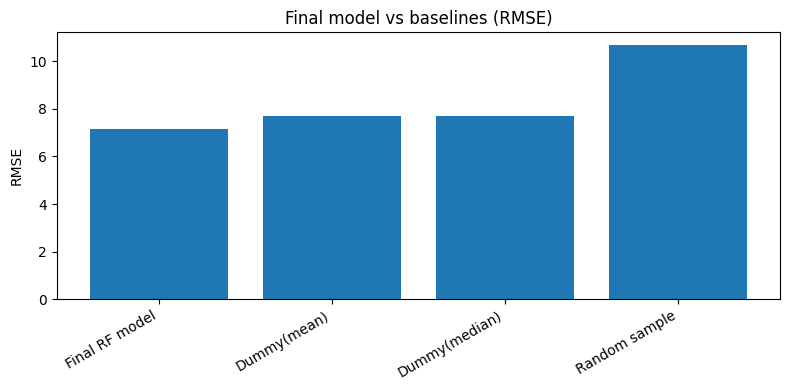

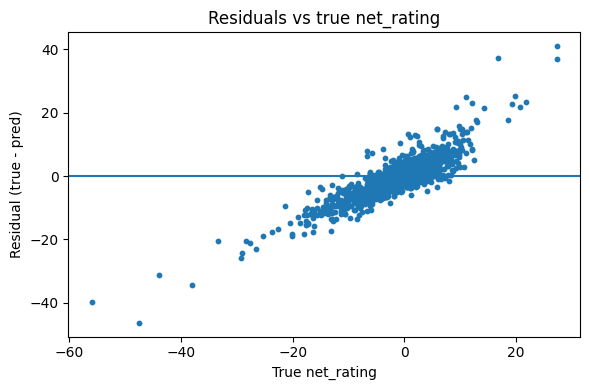

In [ ]:
# ===============================
# 5c) Compare final model vs baselines + segmented evaluation
# ===============================


# --- 1) Comparison table: final model vs baselines ---
final_row = pd.DataFrame([{
    "model": "Final RF model",
    "rmse": float(test_rmse),
    "mae": float(test_mae),
    "r2": float(test_r2)
}])

baseline_rows = baseline_df.rename(columns={"baseline": "model"}).copy()
comparison_df = pd.concat([final_row, baseline_rows], ignore_index=True)

best_baseline_rmse = float(baseline_rows["rmse"].min())
best_baseline_mae  = float(baseline_rows.loc[baseline_rows["rmse"].idxmin(), "mae"])

comparison_df["rmse_improvement_vs_best_baseline_%"] = (
    (best_baseline_rmse - comparison_df["rmse"]) / best_baseline_rmse * 100.0
)
comparison_df["mae_improvement_vs_best_baseline_%"] = (
    (best_baseline_mae - comparison_df["mae"]) / best_baseline_mae * 100.0
)

comparison_df_sorted = comparison_df.sort_values("rmse").reset_index(drop=True)
comparison_df_sorted


# --- 2) Segmented evaluation across target quantiles ---
TARGET_COL = "net_rating"
drop_cols = [TARGET_COL, "player_name", "season", "season_start"]

X_test = test_df.drop(columns=[c for c in drop_cols if c in test_df.columns], errors="ignore")
y_test = test_df[TARGET_COL].astype(float).values

bool_cols = [c for c in X_test.columns if str(X_test[c].dtype) == "bool"]
for c in bool_cols:
    X_test[c] = X_test[c].astype(int)

y_pred = final_model.predict(X_test)

qbin = pd.qcut(y_test, q=4, duplicates="drop")
seg_df = pd.DataFrame({"y_true": y_test, "y_pred": y_pred, "bin": qbin})
seg_df["abs_err"] = np.abs(seg_df["y_true"] - seg_df["y_pred"])
seg_df["sq_err"] = (seg_df["y_true"] - seg_df["y_pred"]) ** 2

segment_metrics = (
    seg_df.groupby("bin")
    .agg(
        n=("y_true", "size"),
        rmse=("sq_err", lambda s: float(np.sqrt(np.mean(s)))),
        mae=("abs_err", lambda s: float(np.mean(s))),
    )
    .reset_index()
)

segment_metrics


# --- 3) Plots  ---
plt.figure(figsize=(8, 4))
plt.bar(comparison_df_sorted["model"], comparison_df_sorted["rmse"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("RMSE")
plt.title("Final model vs baselines (RMSE)")
plt.tight_layout()
plt.show()

residuals = y_test - y_pred
plt.figure(figsize=(6, 4))
plt.scatter(y_test, residuals, s=10)
plt.axhline(0)
plt.xlabel("True net_rating")
plt.ylabel("Residual (true - pred)")
plt.title("Residuals vs true net_rating")
plt.tight_layout()
plt.show()


In [ ]:


# --- 4)
comment_5c = f"""
5c) Comparison of final model vs baselines / benchmarks:

Final model (RF regression) on test set:
RMSE={test_rmse:.4f}, MAE={test_mae:.4f}, R2={test_r2:.4f}.

Baselines (5b-ii):
The DummyRegressor(mean/median) and random-sampling baseline provide lower bounds.
The final model outperforms the best baseline in RMSE/MAE (see comparison table),
indicating that the model learns useful signal beyond trivial prediction.

Benchmark/SOTA (5b-i):
No directly comparable published benchmark for net_rating regression (RMSE/MAE/R2) on this exact
dataset/task was found. Related Kaggle notebooks exist but solve different tasks (classification or
clustering) and therefore are not directly comparable.

Segmented evaluation:
We evaluated error metrics across quantiles of the true net_rating. This highlights whether the model
performs worse in specific regions (e.g., extreme low/high net_rating players).
""".strip()


# --- 5) Provenance triples (5c) ---
start_time_5c = now()

# Store tables as JSON in the KG
comparison_json = comparison_df_sorted.to_json(orient="records", indent=2)
segment_json = segment_metrics.to_json(orient="records", indent=2)

end_time_5c = now()

ass_uuid_5c_writer = "5d5e7041-d1ae-4a42-b0a0-a059d3420504"
ass_uuid_5c_executor = "f0dc9e34-0f44-435f-b204-16b948d04b7f"

triples_5c = [
    ":compare_performance_5c rdf:type prov:Activity .",
    ":compare_performance_5c sc:isPartOf :evaluation_phase .",
    ":compare_performance_5c rdfs:label \"Performance comparison (5c)\" .",
    f":compare_performance_5c rdfs:comment \"\"\"{comment_5c}\"\"\" .",
    f":compare_performance_5c prov:startedAtTime \"{start_time_5c}\"^^xsd:dateTime .",
    f":compare_performance_5c prov:endedAtTime \"{end_time_5c}\"^^xsd:dateTime .",

    # writer association
    f":compare_performance_5c prov:qualifiedAssociation :{ass_uuid_5c_writer} .",
    f":{ass_uuid_5c_writer} prov:agent :{student_b} .",
    f":{ass_uuid_5c_writer} rdf:type prov:Association .",
    f":{ass_uuid_5c_writer} prov:hadRole :{code_writer_role} .",

    # executor association
    f":compare_performance_5c prov:qualifiedAssociation :{ass_uuid_5c_executor} .",
    f":{ass_uuid_5c_executor} prov:agent :{executed_by} .",
    f":{ass_uuid_5c_executor} rdf:type prov:Association .",
    f":{ass_uuid_5c_executor} prov:hadRole :{code_executor_role} .",

    # inputs from earlier steps
    ":compare_performance_5c prov:used :rf_test_metrics .",
    ":compare_performance_5c prov:used :baseline_results_5bii .",
    ":compare_performance_5c prov:used :benchmark_search_5bi .",

    # outputs: comparison table
    ":comparison_table_5c rdf:type prov:Entity .",
    ":comparison_table_5c rdfs:label \"Final vs baseline comparison table (5c)\" .",
    f":comparison_table_5c rdfs:comment \"\"\"{comparison_json}\"\"\" .",
    ":comparison_table_5c prov:wasGeneratedBy :compare_performance_5c .",

    # outputs: segmented evaluation table
    ":segment_metrics_5c rdf:type prov:Entity .",
    ":segment_metrics_5c rdfs:label \"Segmented error metrics by net_rating quantiles (5c)\" .",
    f":segment_metrics_5c rdfs:comment \"\"\"{segment_json}\"\"\" .",
    ":segment_metrics_5c prov:wasGeneratedBy :compare_performance_5c .",
]

engine.insert(triples_5c, prefixes=prefixes)


In [ ]:

# ===============================
# 5d) Compare against success criteria (Business + Data Mining)
# ===============================

TARGET_COL = "net_rating"
drop_cols = [TARGET_COL, "player_name", "season", "season_start"]

# Prepare test set
X_test = test_df.drop(columns=[c for c in drop_cols if c in test_df.columns], errors="ignore")
y_test = test_df[TARGET_COL].astype(float).values

bool_cols = [c for c in X_test.columns if str(X_test[c].dtype) == "bool"]
for c in bool_cols:
    X_test[c] = X_test[c].astype(int)

# Predict
y_pred = final_model.predict(X_test)

# --- Helper values ---
n = len(y_test)
k = int(np.ceil(0.25 * n))  # top 25%
league_avg = float(np.mean(y_test))  # proxy for "league average net_rating" on this test sample

# Indices for top true and top predicted
true_top_idx = np.argsort(y_test)[-k:]
pred_top_idx = np.argsort(y_pred)[-k:]

true_top_set = set(true_top_idx.tolist())
pred_top_set = set(pred_top_idx.tolist())

# ===============================
# Criterion 1: recall in true top 25%
# "of the top 25% true players, how many are captured by predicted top 25%"
# ===============================
recall_top25 = len(true_top_set.intersection(pred_top_set)) / float(k)

# ===============================
# Criterion 2: shortlist quality above league average
# "in predicted top 25%, % above league average (proxy, current-season)"
# Note: "next season" requires next-season labels; if not available, document this proxy.
# ===============================
pred_top_true_values = y_test[list(pred_top_set)]
share_above_avg_in_pred_top25 = float(np.mean(pred_top_true_values > league_avg))
avg_net_rating_pred_top25 = float(np.mean(pred_top_true_values))

# ===============================
# Criterion 3: reduce bad signings vs random/subjective
# We'll quantify "bad signing rate" = share below league average in shortlist.
# Compare predicted top 25% shortlist vs random 25% shortlist (expected).
# ===============================
bad_rate_pred_top25 = float(np.mean(pred_top_true_values < league_avg))
bad_rate_random = float(np.mean(y_test < league_avg))  # expected bad rate when selecting randomly
bad_signing_reduction = (bad_rate_random - bad_rate_pred_top25) / bad_rate_random if bad_rate_random > 0 else np.nan

# ===============================
# Data mining success: beat baseline on RMSE/MAE
# Use your baseline results from 5b(ii)
# ===============================
# Find Dummy(mean) baseline metrics from baseline_df
mean_baseline_row = baseline_df[baseline_df["baseline"].str.contains("Dummy\\(mean\\)", regex=True)].iloc[0]
rmse_mean_baseline = float(mean_baseline_row["rmse"])
mae_mean_baseline  = float(mean_baseline_row["mae"])

rmse_final = float(np.sqrt(mean_squared_error(y_test, y_pred)))
mae_final  = float(mean_absolute_error(y_test, y_pred))

beats_rmse_baseline = rmse_final < rmse_mean_baseline
beats_mae_baseline  = mae_final  < mae_mean_baseline

# --- Collect results into a table ---
criteria_df = pd.DataFrame([{
    "metric": "Recall@Top25% (true top captured)",
    "value": recall_top25,
    "target": ">= 0.70",
    "meets": recall_top25 >= 0.70
},{
    "metric": "Share above league avg in predicted Top25%",
    "value": share_above_avg_in_pred_top25,
    "target": ">= 0.80",
    "meets": share_above_avg_in_pred_top25 >= 0.80
},{
    "metric": "Bad-signing reduction vs random (Top25%)",
    "value": bad_signing_reduction,
    "target": ">= 0.25",
    "meets": (bad_signing_reduction >= 0.25) if not np.isnan(bad_signing_reduction) else False
},{
    "metric": "Beats mean baseline RMSE",
    "value": rmse_final,
    "target": f"< {rmse_mean_baseline:.4f}",
    "meets": beats_rmse_baseline
},{
    "metric": "Beats mean baseline MAE",
    "value": mae_final,
    "target": f"< {mae_mean_baseline:.4f}",
    "meets": beats_mae_baseline
},{
    "metric": "Avg true net_rating of predicted Top25%",
    "value": avg_net_rating_pred_top25,
    "target": f"> league_avg ({league_avg:.4f})",
    "meets": avg_net_rating_pred_top25 > league_avg
}])

criteria_df


,metric,value,target,meets
0,Recall@Top25% (true top captured),0.453125,>= 0.70,False
1,Share above league avg in predicted Top25%,0.835938,>= 0.80,True
2,Bad-signing reduction vs random (Top25%),0.632385,>= 0.25,True
3,Beats mean baseline RMSE,7.166609,< 7.7087,True
4,Beats mean baseline MAE,5.073029,< 5.7604,True
5,Avg true net_rating of predicted Top25%,2.477344,> league_avg (-1.5822),True


In [ ]:
comment_5d = """
5d) Comparison with success criteria (Business Understanding):

We evaluated the final model on the unseen test set and compared results to the success criteria.

Business success criteria:
1) Recall@Top25% (target >= 0.70):
   Observed recall@Top25% = 0.453. This does NOT meet the target. The model’s top-quartile shortlist
   misses a substantial share of the true top-quartile players, indicating ranking/recall limitations.

2) Shortlist quality (target >= 0.80 above league average):
   In the predicted Top25%, 0.836 (83.6%) of players are above the league-average net_rating.
   This meets the criterion and indicates that the shortlist is generally “safe” (contains mostly above-average players).

3) Reduce impact of bad signings (target >= 0.25 reduction vs random):
   Bad-signing reduction vs random selection is 0.632 (63.2%), exceeding the target by a wide margin.
   This suggests the model can substantially reduce below-average signings compared to random selection.

Data mining success criteria:
- Beat mean baseline on RMSE/MAE:
  Final model RMSE=7.1666 vs baseline RMSE=7.7087 (better).
  Final model MAE=5.0730 vs baseline MAE=5.7604 (better).
  Therefore, the model meets the baseline-beating requirement.

Overall conclusion:
The model meets most quantitative success criteria (baseline beating, shortlist quality, and reducing bad signings),
but fails the strict Top25% recall requirement. If top-quartile recall is business-critical, we should consider
methods focused on ranking/recall (e.g., optimizing for top-k recall, changing threshold, additional features,
or alternate models/objectives).
""".strip()

start_time_5d = now()
end_time_5d = now()

ass_uuid_5d_writer = "ceb30192-abda-428d-bd64-d7434546140d"
ass_uuid_5d_executor = "9f2a0f88-57b7-4f65-a809-8a425216b263"

criteria_json = criteria_df.to_json(orient="records", indent=2)

triples_5d = [
    ":success_criteria_check_5d rdf:type prov:Activity .",
    ":success_criteria_check_5d sc:isPartOf :evaluation_phase .",
    ":success_criteria_check_5d rdfs:label \"Compare performance vs success criteria (5d)\" .",
    f":success_criteria_check_5d rdfs:comment \"\"\"{comment_5d}\"\"\" .",
    f":success_criteria_check_5d prov:startedAtTime \"{start_time_5d}\"^^xsd:dateTime .",
    f":success_criteria_check_5d prov:endedAtTime \"{end_time_5d}\"^^xsd:dateTime .",

    # writer
    f":success_criteria_check_5d prov:qualifiedAssociation :{ass_uuid_5d_writer} .",
    f":{ass_uuid_5d_writer} prov:agent :{student_b} .",
    f":{ass_uuid_5d_writer} rdf:type prov:Association .",
    f":{ass_uuid_5d_writer} prov:hadRole :{code_writer_role} .",

    # executor
    f":success_criteria_check_5d prov:qualifiedAssociation :{ass_uuid_5d_executor} .",
    f":{ass_uuid_5d_executor} prov:agent :{executed_by} .",
    f":{ass_uuid_5d_executor} rdf:type prov:Association .",
    f":{ass_uuid_5d_executor} prov:hadRole :{code_executor_role} .",

    # inputs
    ":success_criteria_check_5d prov:used :final_rf_model .",
    ":success_criteria_check_5d prov:used :test_set .",
    ":success_criteria_check_5d prov:used :bu_business_success_criteria .",
    ":success_criteria_check_5d prov:used :bu_data_mining_success_criteria .",
    ":success_criteria_check_5d prov:used :baseline_results_5bii .",

    # outputs
    ":success_criteria_results_5d rdf:type prov:Entity .",
    ":success_criteria_results_5d rdfs:label \"Success criteria evaluation results (5d)\" .",
    f":success_criteria_results_5d rdfs:comment \"\"\"{criteria_json}\"\"\" .",
    ":success_criteria_results_5d prov:wasGeneratedBy :success_criteria_check_5d .",
]

engine.insert(triples_5d, prefixes=prefixes)


In [ ]:
def group_bias_report(test_df, y_true, y_pred, group_col, min_group_size=30, top_k_groups=12):
    """
    Regression fairness check: compare error metrics across groups.
    Filters small groups to avoid noisy conclusions.
    """
    df = test_df[[group_col]].copy()
    df["y_true"] = y_true
    df["y_pred"] = y_pred
    df["err"] = df["y_true"] - df["y_pred"]
    df["abs_err"] = np.abs(df["err"])
    df["sq_err"] = df["err"] ** 2

    # group sizes
    counts = df[group_col].value_counts(dropna=False)

    # Keep only sufficiently large groups
    keep_groups = counts[counts >= min_group_size].index
    df_f = df[df[group_col].isin(keep_groups)].copy()

    # If too many groups, keep top-K by count for readability
    keep_groups_top = df_f[group_col].value_counts().head(top_k_groups).index
    df_f = df_f[df_f[group_col].isin(keep_groups_top)].copy()

    g = df_f.groupby(group_col).agg(
        n=("y_true", "size"),
        rmse=("sq_err", lambda s: float(np.sqrt(np.mean(s)))),
        mae=("abs_err", lambda s: float(np.mean(s))),
        mean_error=("err", lambda s: float(np.mean(s))),  # signed error: positive => underpredict
        mean_true=("y_true", "mean"),
        mean_pred=("y_pred", "mean"),
    ).reset_index()

    # overall metrics on filtered set
    overall_rmse = float(np.sqrt(np.mean(df_f["sq_err"])))
    overall_mae = float(np.mean(df_f["abs_err"]))
    overall_mean_err = float(np.mean(df_f["err"]))

    # gap measures
    rmse_gap = float(g["rmse"].max() - g["rmse"].min()) if len(g) else np.nan
    mae_gap = float(g["mae"].max() - g["mae"].min()) if len(g) else np.nan

    g_sorted = g.sort_values("rmse", ascending=False).reset_index(drop=True)
    summary = {
        "group_col": group_col,
        "min_group_size": min_group_size,
        "groups_included": int(len(g_sorted)),
        "overall_rmse_filtered": overall_rmse,
        "overall_mae_filtered": overall_mae,
        "overall_mean_error_filtered": overall_mean_err,
        "rmse_gap_max_minus_min": rmse_gap,
        "mae_gap_max_minus_min": mae_gap,
    }
    return g_sorted, summary

# ---- Run for COUNTRY ----
country_metrics, country_summary = group_bias_report(
    test_df=test_df, y_true=y_test, y_pred=y_pred, group_col="country", min_group_size=30, top_k_groups=12
)
country_summary, country_metrics.head(20)


({'group_col': 'country',
  'min_group_size': 30,
  'groups_included': 2,
  'overall_rmse_filtered': 7.020026593280685,
  'overall_mae_filtered': 4.984737292200174,
  'overall_mean_error_filtered': -0.7700632044503974,
  'rmse_gap_max_minus_min': 0.42950490096693184,
  'mae_gap_max_minus_min': 0.5218404159519485},
   country    n      rmse       mae  mean_error  mean_true  mean_pred
 0  Canada   42  7.426894  5.479849   -1.330088  -2.311905  -0.981816
 1     USA  778  6.997389  4.958009   -0.739830  -1.662339  -0.922509)

In [ ]:
# ---- Run for COLLEGE ----
college_metrics, college_summary = group_bias_report(
    test_df=test_df, y_true=y_test, y_pred=y_pred, group_col="college", min_group_size=30, top_k_groups=12
)
college_summary, college_metrics.head(20)


({'group_col': 'college',
  'min_group_size': 30,
  'groups_included': 3,
  'overall_rmse_filtered': 7.820651094031398,
  'overall_mae_filtered': 5.366141939676354,
  'overall_mean_error_filtered': -0.9535399613553316,
  'rmse_gap_max_minus_min': 2.645968089066419,
  'mae_gap_max_minus_min': 1.28576797245013},
       college    n      rmse       mae  mean_error  mean_true  mean_pred
 0  no_college  133  8.384766  5.872257   -0.781337  -1.911278  -1.129942
 1        Duke   46  8.275440  4.835004   -1.566257  -2.271739  -0.705482
 2    Kentucky   55  5.738798  4.586489   -0.857505  -1.058182  -0.200677)

In [ ]:
comment_5e = """
5e) Bias / subgroup performance evaluation (regression):

Protected/subgroup attributes evaluated:
- country (potentially sensitive attribute)
- college (subgroup attribute / background proxy)

Method:
We computed per-group RMSE, MAE, and mean signed error (y_true - y_pred) on the test set.
Small groups were filtered out (min size = 30). Results were limited to the largest groups that meet this threshold.

Country results (min size = 30):
Only two countries met the threshold: USA (n=778) and Canada (n=42).
RMSE gap (max-min) = 0.4295 and MAE gap (max-min) = 0.5218, which are relatively small.
Mean signed error is negative for both groups (USA: -0.7398, Canada: -1.3301), indicating the model tends to
slightly overpredict net_rating on average; this effect is somewhat stronger for Canada.
Given the small Canada sample size, conclusions for country are limited, but we do not observe strong evidence
of major performance disparity across the available country groups.

College results (min size = 30):
Three college groups met the threshold: no_college (n=133), Duke (n=46), Kentucky (n=55).
Error differences are substantially larger: RMSE gap = 2.6460 and MAE gap = 1.2858.
The model performs worst for no_college (RMSE 8.3848, MAE 5.8723) and Duke (RMSE 8.2754),
and best for Kentucky (RMSE 5.7388, MAE 4.5865). This indicates uneven predictive performance
across subgroups defined by college, which may reflect data imbalance, different feature distributions,
or systematic differences in how well the available attributes explain net_rating for these groups.

Implications:
Country does not show a strong disparity in this filtered analysis, while college shows notable subgroup
performance gaps. For deployment, subgroup monitoring is recommended; potential mitigations include collecting
more data for underrepresented groups, adding explanatory features, or using group-aware evaluation/weighting.
""".strip()

start_time_5e = now()
end_time_5e = now()

ass_uuid_5e_writer = "8dadc55c-7a10-4e48-99ef-0d1cea7c23aa"
ass_uuid_5e_executor = "e0d5ec8b-53af-4357-9201-42d4d5b25172"

country_json = country_metrics.to_json(orient="records", indent=2)
college_json = college_metrics.to_json(orient="records", indent=2)

triples_5e = [
    ":bias_eval_5e rdf:type prov:Activity .",
    ":bias_eval_5e sc:isPartOf :evaluation_phase .",
    ":bias_eval_5e rdfs:label \"Bias / subgroup evaluation (5e)\" .",
    f":bias_eval_5e rdfs:comment \"\"\"{comment_5e}\"\"\" .",
    f":bias_eval_5e prov:startedAtTime \"{start_time_5e}\"^^xsd:dateTime .",
    f":bias_eval_5e prov:endedAtTime \"{end_time_5e}\"^^xsd:dateTime .",

    # writer
    f":bias_eval_5e prov:qualifiedAssociation :{ass_uuid_5e_writer} .",
    f":{ass_uuid_5e_writer} prov:agent :{student_b} .",
    f":{ass_uuid_5e_writer} rdf:type prov:Association .",
    f":{ass_uuid_5e_writer} prov:hadRole :{code_writer_role} .",

    # executor
    f":bias_eval_5e prov:qualifiedAssociation :{ass_uuid_5e_executor} .",
    f":{ass_uuid_5e_executor} prov:agent :{executed_by} .",
    f":{ass_uuid_5e_executor} rdf:type prov:Association .",
    f":{ass_uuid_5e_executor} prov:hadRole :{code_executor_role} .",

    # inputs
    ":bias_eval_5e prov:used :final_rf_model .",
    ":bias_eval_5e prov:used :test_set .",

    # outputs: country
    ":bias_by_country_5e rdf:type prov:Entity .",
    ":bias_by_country_5e rdfs:label \"Subgroup metrics by country (5e)\" .",
    f":bias_by_country_5e rdfs:comment \"\"\"{country_json}\"\"\" .",
    ":bias_by_country_5e prov:wasGeneratedBy :bias_eval_5e .",

    # outputs: college
    ":bias_by_college_5e rdf:type prov:Entity .",
    ":bias_by_college_5e rdfs:label \"Subgroup metrics by college (5e)\" .",
    f":bias_by_college_5e rdfs:comment \"\"\"{college_json}\"\"\" .",
    ":bias_by_college_5e prov:wasGeneratedBy :bias_eval_5e .",
]

engine.insert(triples_5e, prefixes=prefixes)


In [ ]:
test_query = f"""
{prefix_header}
SELECT ?s ?p ?o WHERE {{
  ?s ?p ?o .
}} LIMIT 30
"""
engine.query(test_query)

,s,p,o
0,<http://www.w3.org/1999/02/22-rdf-syntax-ns#type>,<http://www.w3.org/1999/02/22-rdf-syntax-ns#type>,<http://www.w3.org/1999/02/22-rdf-syntax-ns#Property>
1,<http://www.w3.org/2000/01/rdf-schema#subPropertyOf>,<http://www.w3.org/1999/02/22-rdf-syntax-ns#type>,<http://www.w3.org/1999/02/22-rdf-syntax-ns#Property>
2,<http://www.w3.org/2000/01/rdf-schema#subPropertyOf>,<http://www.w3.org/1999/02/22-rdf-syntax-ns#type>,<http://www.w3.org/2002/07/owl#TransitiveProperty>
3,<http://www.w3.org/2000/01/rdf-schema#subClassOf>,<http://www.w3.org/1999/02/22-rdf-syntax-ns#type>,<http://www.w3.org/1999/02/22-rdf-syntax-ns#Property>
4,<http://www.w3.org/2000/01/rdf-schema#subClassOf>,<http://www.w3.org/1999/02/22-rdf-syntax-ns#type>,<http://www.w3.org/2002/07/owl#TransitiveProperty>
5,<http://www.w3.org/2000/01/rdf-schema#domain>,<http://www.w3.org/1999/02/22-rdf-syntax-ns#type>,<http://www.w3.org/1999/02/22-rdf-syntax-ns#Property>
6,<http://www.w3.org/2000/01/rdf-schema#range>,<http://www.w3.org/1999/02/22-rdf-syntax-ns#type>,<http://www.w3.org/1999/02/22-rdf-syntax-ns#Property>
7,<http://www.w3.org/2002/07/owl#equivalentProperty>,<http://www.w3.org/1999/02/22-rdf-syntax-ns#type>,<http://www.w3.org/2002/07/owl#SymmetricProperty>
8,<http://www.w3.org/2002/07/owl#equivalentProperty>,<http://www.w3.org/1999/02/22-rdf-syntax-ns#type>,<http://www.w3.org/2002/07/owl#TransitiveProperty>
9,<http://www.w3.org/2002/07/owl#equivalentClass>,<http://www.w3.org/1999/02/22-rdf-syntax-ns#type>,<http://www.w3.org/2002/07/owl#SymmetricProperty>


## Deployment

In [ ]:
## Each Activity that follows is part of the Deployment Phase

deployment_phase_executor = [
f':deployment_phase rdf:type prov:Activity .',
f':deployment_phase rdfs:label "Deployment Phase" .', 
]
engine.insert(deployment_phase_executor, prefixes=prefixes)

In [ ]:
# ===============================
# Deployment 
# ===============================

comparison_and_recommendations_comment = """
6a) Business objectives + deployment recommendation

The model is useful but not perfect.

What is good:
- It beats the simple baseline (mean predictor) on RMSE and MAE.
- The Top25% predicted list is mostly good players: about 84% are above league average net_rating.
- Compared to random selection it reduces bad signings a lot (~63% reduction).

What is missing:
- Recall@Top25% is only ~0.45 (target was 0.70). So the model does not catch most of the real top players.

Conclusion:
The business objective is partly met: the model helps reduce risk (avoid bad signings) and supports scouting,
but it should not be used to automatically pick the “best” players.

Deployment recommendation:
- Use hybrid/human-in-the-loop: model creates shortlist, humans decide final signings.
- Use it mainly as a filter to avoid below-average players.
- Next: improve recall@Top25% (better features, ranking approach, next-season labels if available).
""".strip()



start_time_dep = now()
end_time_dep = now()

dep_ass_uuid_executor = "be84c41f-8018-4b75-8781-6fa1c588b81b"  

deployment_executor = [
    ":plan_deployment rdf:type prov:Activity .",
    ":plan_deployment sc:isPartOf :deployment_phase .",
    ":plan_deployment rdfs:label \"Plan Deployment\"@en .",
    f":plan_deployment prov:startedAtTime \"{start_time_dep}\"^^xsd:dateTime .",
    f":plan_deployment prov:endedAtTime \"{end_time_dep}\"^^xsd:dateTime .",

    f":plan_deployment prov:qualifiedAssociation :{dep_ass_uuid_executor} .",
    f":{dep_ass_uuid_executor} prov:agent :{executed_by} .",
    f":{dep_ass_uuid_executor} rdf:type prov:Association .",
    f":{dep_ass_uuid_executor} prov:hadRole :{code_executor_role} .",
]
engine.insert(deployment_executor, prefixes=prefixes)


deployment_6a = [
    ":dep_recommendations rdf:type prov:Entity .",
    ":dep_recommendations prov:wasGeneratedBy :plan_deployment .",
    ":dep_recommendations rdfs:label \"6a Business Objectives Reflection and Deployment Recommendations\" .",
    f":dep_recommendations rdfs:comment \"\"\"{comparison_and_recommendations_comment}\"\"\" .",

    # Link to BU objectives/success criteria + evaluation results (rename URIs if yours differ)
    ":dep_recommendations prov:used :bu_business_objectives .",
    ":dep_recommendations prov:used :bu_business_success_criteria .",
    ":dep_recommendations prov:used :success_criteria_results_5d .",
    ":dep_recommendations prov:used :rf_test_metrics .",
    ":dep_recommendations prov:used :baseline_results_5bii .",
]
engine.insert(deployment_6a, prefixes=prefixes)


ethical_aspects_comment = """
6b) Ethical aspects + risks

Main risk: people may trust the model too much (automation bias). Final decisions should stay with humans.

Bias / subgroup risk (from 5e):
- Country: only USA/Canada had enough data; difference was small (limited conclusion).
- College: bigger performance differences across groups (e.g., Kentucky vs Duke/no_college).
So the model is not equally accurate for all subgroups.

Mitigation:
- Monitor subgroup performance (especially college).
- Retrain regularly (new season data -> drift).
- Use other context too (injuries, role, minutes, scouting reports).
""".strip()


deployment_6b = [
    ":dep_ethical_risks rdf:type prov:Entity .",
    ":dep_ethical_risks prov:wasGeneratedBy :plan_deployment .",
    ":dep_ethical_risks rdfs:label \"6b Ethical Aspects and Risks\" .",
    f":dep_ethical_risks rdfs:comment \"\"\"{ethical_aspects_comment}\"\"\" .",

    # Link to bias/risk items (rename URIs if yours differ)
    ":dep_ethical_risks prov:used :bias_eval_5e .",
    ":dep_ethical_risks prov:used :bias_by_country_5e .",
    ":dep_ethical_risks prov:used :bias_by_college_5e .",
]
engine.insert(deployment_6b, prefixes=prefixes)


In [ ]:
##############################################
## Documentation
##############################################
#
#comparison_and_recommendations_comment = """
#...
#"""
#
#ethical_aspects_comment = """
#...
#"""
#
#monitoring_plan_comment = """
#...
#"""
#
#reproducibility_reflection_comment = """
#...
#"""
#
#dep_ass_uuid_executor = "72a921e0-1234-4567-89ab-cdef01234567" # Generate once
#deployment_executor = [
#f':plan_deployment rdf:type prov:Activity .',
#f':plan_deployment sc:isPartOf :deployment_phase .', # Connect to Parent Phase
#f':plan_deployment rdfs:label "Plan Deployment"@en .',
#
#f':plan_deployment prov:qualifiedAssociation :{dep_ass_uuid_executor} .',
#f':{dep_ass_uuid_executor} prov:agent :{executed_by} .',
#f':{dep_ass_uuid_executor} rdf:type prov:Association .',
#f':{dep_ass_uuid_executor} prov:hadRole :{code_executor_role} .', 
#]
#engine.insert(deployment_executor, prefixes=prefixes)
#
#
#deployment_data_executor = [
##6a
#f':dep_recommendations rdf:type prov:Entity .',
#f':dep_recommendations prov:wasGeneratedBy :plan_deployment .',
#f':dep_recommendations rdfs:label "6a Business Objectives Reflection and Deployment Recommendations" .',
#f':dep_recommendations rdfs:comment """{comparison_and_recommendations_comment}""" .',
##6b
#f':dep_ethical_risks rdf:type prov:Entity .',
#f':dep_ethical_risks prov:wasGeneratedBy :plan_deployment .',
#f':dep_ethical_risks rdfs:label "6b Ethical Aspects and Risks" .',
#f':dep_ethical_risks rdfs:comment """{ethical_aspects_comment}""" .',
##6c
#f':dep_monitoring_plan rdf:type prov:Entity .',
#f':dep_monitoring_plan prov:wasGeneratedBy :plan_deployment .',
#f':dep_monitoring_plan rdfs:label "6c Monitoring Plan" .',
#f':dep_monitoring_plan rdfs:comment """{monitoring_plan_comment}""" .',
##6d
#f':dep_reproducibility_reflection rdf:type prov:Entity .',
#f':dep_reproducibility_reflection prov:wasGeneratedBy :plan_deployment .',
#f':dep_reproducibility_reflection rdfs:label "6d Reproducibility Reflection" .',
#f':dep_reproducibility_reflection rdfs:comment """{reproducibility_reflection_comment}""" .',
#
#]
#engine.insert(deployment_data_executor, prefixes=prefixes)

# Generate Latex Report

The following cells give you an example of how to automatically create a Latex Report from your provenance documentation.

Feel free to use the example provided. If you use it, you should adapt and extend it with relevant sections/tables/plots/... 

In [ ]:
base_iri = f"https://starvers.ec.tuwien.ac.at/BI2025/{group_id}/"

In [ ]:
# This cell includes cleaning functions

from datetime import datetime

def latex_escape(text: str | None) -> str:
    if text is None: return ""
    text = str(text)
    text = text.replace("\\", r"\textbackslash{}")
    pairs = [
        ("&", r"\&"), ("%", r"\%"), ("$", r"\$"), ("#", r"\#"), 
        ("_", r"\_"), ("{", r"\{"), ("}", r"\}"), 
        ("~", r"\textasciitilde{}"), ("^", r"\textasciicircum{}")
    ]
    for k, v in pairs:
        text = text.replace(k, v)
    return text

def clean_rdf(x) -> str:
    if hasattr(x, "toPython"): return str(x.toPython())
    if x is None: return ""
    s = str(x).strip()
    s = s.strip('"').strip("'")
    s = s.strip()
    if "^^" in s:
        s = s.split("^^")[0].strip('"')
        
    return s

def fmt_iso(ts: str) -> str:
    if not ts: return ""
    try:
        clean_ts = ts.split("^^")[0].strip('"')
        clean_ts = clean_ts.replace("Z", "+00:00") if clean_ts.endswith("Z") else clean_ts
        return datetime.fromisoformat(clean_ts).strftime("%Y-%m-%d %H:%M:%S")
    except:
        return latex_escape(str(ts))

In [ ]:
# Disable timestamped queries (avoids Windows timezone problems)
orig_query = engine.query

def query_no_timestamp(select_statement, **kwargs):
    kwargs["yn_timestamp_query"] = False
    return orig_query(select_statement, **kwargs)

engine.query = query_no_timestamp


In [ ]:
# This cell includes exemplary queries for different phases


### Author Block
author_query = f"""
{prefix_header}
PREFIX iao: <http://purl.obolibrary.org/obo/>

SELECT DISTINCT ?uri ?given ?family ?matr WHERE {{
  VALUES ?uri {{ :{student_a} :{student_b} }}
  
  ?uri a foaf:Person .
  ?uri foaf:givenName ?given .
  ?uri foaf:familyName ?family .
  ?uri iao:IAO_0000219 ?matr .
}}
"""

res_authors = engine.query(author_query)
author_block_latex = ""

if not res_authors.empty: # type:ignore
    for _, row in res_authors.iterrows(): # type:ignore

        uri_str = str(row['uri'])
        given = latex_escape(clean_rdf(row['given']))
        family = latex_escape(clean_rdf(row['family']))
        matr = latex_escape(clean_rdf(row['matr']))
        if student_a in uri_str:
            responsibility = "Student A"
        elif student_b in uri_str:
            responsibility = "Student B"
        else:
            responsibility = "Student"
        
        author_block_latex += rf"""
          \author{{{given} {family}}}
          \authornote{{{responsibility}, Matr.Nr.: {matr}}}
          \affiliation{{
            \institution{{TU Wien}}
            \country{{Austria}}
          }}
          """

### Business Understanding example
bu_query = f"""
{prefix_header}

SELECT ?ds_comment ?bo_comment WHERE {{
  OPTIONAL {{ :bu_data_source_and_scenario rdfs:comment ?ds_comment . }}
  OPTIONAL {{ :bu_business_objectives rdfs:comment ?bo_comment . }}
}} LIMIT 1
"""
res_bu = engine.query(bu_query)
row_bu = res_bu.iloc[0] if not res_bu.empty else {} # type:ignore
bu_data_source = latex_escape(clean_rdf(row_bu.get("ds_comment", "")))
bu_objectives  = latex_escape(clean_rdf(row_bu.get("bo_comment", "")))


### Data Understanding examples
# Example Dataset Description
du_desc_query = f"""
{prefix_header}
SELECT ?desc WHERE {{ :raw_data sc:description ?desc . }} LIMIT 1
"""
res_du_desc = engine.query(du_desc_query)
row_du_desc = res_du_desc.iloc[0] if not res_du_desc.empty else {} # type:ignore
du_description = latex_escape(clean_rdf(row_du_desc.get("desc", "")))

# Example Feature Columns Table
du_query = f"""
{prefix_header}

SELECT ?name (SAMPLE(?dtypeRaw) as ?dtype) (SAMPLE(?descRaw) as ?desc) WHERE {{
  :raw_data cr:recordSet ?rs .
  ?rs cr:field ?field .
  ?field sc:name ?name .
  ?field sc:description ?descRaw .
  ?field cr:dataType ?dtypeRaw .
}} 
GROUP BY ?name
ORDER BY ?name
"""
res_du = engine.query(du_query)
du_rows = []
if not res_du.empty: # type:ignore
    for _, f in res_du.iterrows(): # type:ignore
        dtype_raw = clean_rdf(f.get("dtype", ""))
        if '#' in dtype_raw: dtype = dtype_raw.split('#')[-1]
        elif '/' in dtype_raw: dtype = dtype_raw.split('/')[-1]
        else: dtype = dtype_raw
        
        desc = clean_rdf(f.get("desc", ""))
        row_str = f"{latex_escape(clean_rdf(f['name']))} & {latex_escape(dtype)} & {latex_escape(desc)} \\\\"
        du_rows.append(row_str)
du_table_rows = "\n    ".join(du_rows)

### Modeling example
# Hyperparameters
hp_query = f"""
{prefix_header}

SELECT ?hpName (SAMPLE(?hpValRaw) as ?hpVal) (MAX(?hpDescRaw) as ?hpDesc) WHERE {{
  ?run sc:isPartOf :train_and_finetune_model .
  ?run mls:hasInput ?setting .
  ?setting a mls:HyperParameterSetting .
  ?setting mls:hasValue ?hpValRaw .
  ?setting mls:specifiedBy ?hpDef .
  ?hpDef rdfs:label ?hpName .
  OPTIONAL {{ ?hpDef rdfs:comment ?hpDescRaw . }}
}} 
GROUP BY ?hpName
ORDER BY ?hpName
"""
res_hp = engine.query(hp_query)
hp_rows = []
if not res_hp.empty: #type:ignore
    for _, row in res_hp.iterrows(): #type:ignore
        name = latex_escape(clean_rdf(row['hpName']))
        val  = latex_escape(clean_rdf(row['hpVal']))
        desc = latex_escape(clean_rdf(row.get('hpDesc', '')))
        hp_rows.append(rf"{name} & {desc} & {val} \\")

hp_table_rows = "\n    ".join(hp_rows)

# Run Info
run_query = f"""
{prefix_header}

SELECT ?algoLabel ?start ?end ?metricLabel ?metricVal WHERE {{
  OPTIONAL {{ :train_and_finetune_model prov:startedAtTime ?start ; prov:endedAtTime ?end . }}
  OPTIONAL {{
      ?run sc:isPartOf :train_and_finetune_model .
      ?run mls:realizes ?algo .
      ?algo rdfs:label ?algoLabel .
  }}
  OPTIONAL {{
    ?run sc:isPartOf :train_and_finetune_model .
    ?run mls:hasOutput ?eval .
    ?eval a mls:ModelEvaluation ; mls:hasValue ?metricVal .
    OPTIONAL {{ ?eval mls:specifiedBy ?m . ?m rdfs:label ?metricLabel . }}
  }}
}} LIMIT 1
"""
res_run = engine.query(run_query)
row_run = res_run.iloc[0] if not res_run.empty else {} #type:ignore
mod_algo  = latex_escape(clean_rdf(row_run.get("algoLabel", "")))
mod_start = latex_escape(fmt_iso(clean_rdf(row_run.get("start"))))
mod_end   = latex_escape(fmt_iso(clean_rdf(row_run.get("end"))))
mod_m_lbl = latex_escape(clean_rdf(row_run.get("metricLabel", "")))
raw_val = clean_rdf(row_run.get('metricVal', ''))
mod_m_val = f"{float(raw_val):.4f}" if raw_val else ""

print("Data extraction done.")

Data extraction done.


The following includes the Latex report itself. It fills in the query-results from the cell before. The ACM Template is already filled. 
Make sure that you update Student A and B accordingly.

In [ ]:
latex_content = rf"""\documentclass[sigconf]{{acmart}}

\AtBeginDocument{{ \providecommand\BibTeX{{ Bib\TeX }} }}
\setcopyright{{acmlicensed}}
\copyrightyear{{2025}}
\acmYear{{2025}}
\acmDOI{{XXXXXXX.XXXXXXX}}

\acmConference[BI 2025]{{Business Intelligence}}{{-}}{{-}}

\begin{{document}}

\title{{BI2025 Experiment Report - Group {group_id}}}
%% ---Authors: Dynamically added ---
{author_block_latex}

\begin{{abstract}}
  This report documents the machine learning experiment for Group {group_id}, following the CRISP-DM process model.
\end{{abstract}}

\ccsdesc[500]{{Computing methodologies~Machine learning}}
\keywords{{CRISP-DM, Provenance, Knowledge Graph, Machine Learning}}

\maketitle

%% --- 1. Business Understanding ---
\section{{Business Understanding}}

\subsection{{Data Source and Scenario}}
{bu_data_source}

\subsection{{Business Objectives}}
{bu_objectives}

%% --- 2. Data Understanding ---
\section{{Data Understanding}}
\textbf{{Dataset Description:}} {du_description}

The following features were identified in the dataset:

\begin{{table}}[h]
  \caption{{Raw Data Features}}
  \label{{tab:features}}
  \begin{{tabular}}{{lp{{0.2\linewidth}}p{{0.4\linewidth}}}}
    \toprule
    \textbf{{Feature Name}} & \textbf{{Data Type}} & \textbf{{Description}} \\
    \midrule
    {du_table_rows}
    \bottomrule
  \end{{tabular}}
\end{{table}}

%% --- 3. Data Preparation ---
\section{{Data Preparation}}
\subsection{{Data Cleaning}}
Describe your Data preparation steps here and include respective graph data.


%% --- 4. Modeling ---
\section{{Modeling}}

\subsection{{Hyperparameter Configuration}}
The model was trained using the following hyperparameter settings:

\begin{{table}}[h]
  \caption{{Hyperparameter Settings}}
  \label{{tab:hyperparams}}
  \begin{{tabular}}{{lp{{0.4\linewidth}}l}}
    \toprule
    \textbf{{Parameter}} & \textbf{{Description}} & \textbf{{Value}} \\
    \midrule
    {hp_table_rows}
    \bottomrule
  \end{{tabular}}
\end{{table}}

\subsection{{Training Run}}
A training run was executed with the following characteristics:
\begin{{itemize}}
    \item \textbf{{Algorithm:}} {mod_algo}
    \item \textbf{{Start Time:}} {mod_start}
    \item \textbf{{End Time:}} {mod_end}
    \item \textbf{{Result:}} {mod_m_lbl} = {mod_m_val}
\end{{itemize}}

%% --- 5. Evaluation ---
\section{{Evaluation}}

%% --- 6. Deployment ---
\section{{Deployment}}

\section{{Conclusion}}

\end{{document}}
"""

In [ ]:
# This cell stores the Latex report to the data/report directory

out_dir = os.path.join("data", "report")
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, "experiment_report.tex")

with open(out_path, "w", encoding="utf-8") as f:
    f.write(latex_content)

print(f"Report written to: {out_path}")

Report written to: data\report\experiment_report.tex
